In [1]:
import numpy as np
import nesspy_analysis as npa
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
base_path = Path("/Volumes/2025/2026/40_160_DFS/F-20_K0")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos()
data = analysis_2.get_data()
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
time = data["t"][data["dphi"] == data["dphi"].min()]
ref_time = float(1./time)*2*40**2
ref_time = float(data["growth_speed"][data["dphi"] == data["dphi"].min()])

ref_dtime = data["delta_growth_speed"][data["dphi"] == data["dphi"].min()]

print(data["dphi"].min())

INFO:root:Initialized DynamicalOrderDisorder analysis for no_inert_states with 13 CSV files


0.09963530742174369


/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/805917536.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ref_time = float(1./time)*2*40**2
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/805917536.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ref_time = float(data["growth_speed"][data["dphi"] == data["dphi"].min()])


/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/3753337008.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/3753337008.py:50: RuntimeWarning: invalid value encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]


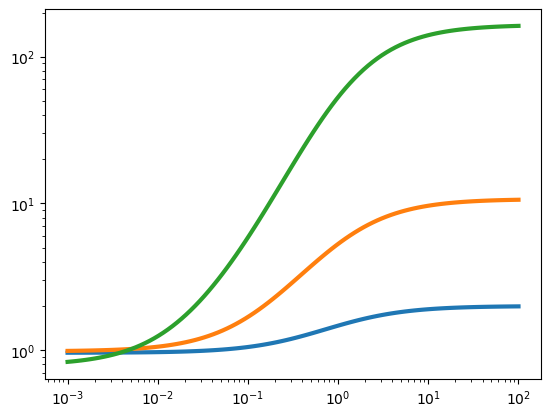

In [3]:
def calc_v_eff_from_flex(k, mu, df, dmu, eii, eij):
    U = np.exp(2*eii)
    U_2 = np.exp(2*eij)
    M = np.exp(dmu)
    F= np.exp(df)
    z = np.exp(mu)

# Set up the generator matrix

    L = np.array([
    [-2*(z + z*F), z, z*F, z, z*F],
    [U, -U-U*k*F*M, U*k*F*M, 0, 0],
    [1.0, k, -(k + 1), 0, 0],
    [U_2, 0.0, 0.0, -U_2*(1+F*M*k), U_2*F*M*k],
    [1.0, 0.0, 0.0, k, -(1+k)]
], dtype=np.float64)
    Q = L.T
    evals, evecs = np.linalg.eig(Q)
    evals = np.round(evals, decimals=10)
    evecs = np.round(evecs, decimals=10)
# Sort eigenvalues and eigenvectors by eigenvalue
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    # print("Eigenvalues:", evals)

# Make sure the first eigenvector is positive
    if evecs[0, 0] < 0:
        evecs[:, 0] = -evecs[:, 0]
# The stationary distribution is the eigenvector associated with eigenvalue 0
    pi = evecs[:, 0] / np.sum(evecs[:, 0])
    # print("Stationary distribution:", pi)

# Construct the Drazin psuedoinverse
    n = Q.shape[0]
    Z = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        if np.abs(evals[i]) < 1e-10:
            Z[i, i] = 0
        else:
            Z[i, i] = 1.0 / evals[i]

    Q_drazin = evecs @ Z @ np.linalg.inv(evecs)
    # print(Q_drazin)

    m = np.ones((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(n):
            m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]

    m = m.T

    v_e_to_active = 1./m[0, 1]
    v_active_to_e = 1./m[1, 0]

    v_eff = v_e_to_active - v_active_to_e

    return v_eff

# The DCP dphi is the same for all of them. So by finding mu(F,dphi_c) I should be able to get good results
# Solve for mu where dphi = 0.3

def find_mu_for_dphi(df, k,dmu, dphi_c=0.3):
    solutions = []
    for mu in np.linspace(-7,-2,10000):
        thermos = npa.Thermos(fres=df, dmu=dmu, k=k, method='NODRIVE')
        dphi = npa.calculate_dphi(mu, thermos)
        if np.isclose(dphi, dphi_c, atol=1e-3):
            solutions.append(mu)
    return np.average(solutions)

blues = sns.color_palette(palette='Blues_d')
reds = sns.color_palette(palette='Reds_d')
greens = sns.color_palette(palette='Greens_d')


FS_TITLE = 14
FS_LEGEND = 16



k_range = np.logspace(-3,2,100)
v_effs = []
v_effs_f0 = []
v_effs_f2 = []
v_effs_f4 = []

for k in k_range:
    df = -20.0
    mu = -6.9
    v_eff = calc_v_eff_from_flex(k, mu, df, 0.0, -3.5, -2.0)
    ref = v_eff

    df = 0.0
    mu = -6.9
    v_eff = calc_v_eff_from_flex(k, mu, df, 0.0, -3.5, -2.0)
    v_effs_f0.append(v_eff/ref)

    df = 2.0

    mu = -6.886
    v_eff = calc_v_eff_from_flex(k, mu, df, 0.0, -3.5, -2.0)
    v_effs_f2.append(v_eff/ref)

    df = 4.0
    mu = -6.795
    v_eff = calc_v_eff_from_flex(k, mu, df, 0.0, -3.5, -2.0)
    v_effs_f4.append(v_eff/ref)

plt.plot(k_range, v_effs_f0, lw=3, label='f0')
plt.plot(k_range, v_effs_f2, lw=3, label='f2')
plt.plot(k_range, v_effs_f4, lw=3, label='f4')
# plt.plot(k_range, -np.array(v_effs_f4), lw=3, label='f4')


plt.yscale('log')
plt.xscale('log')


[-6.82982983]


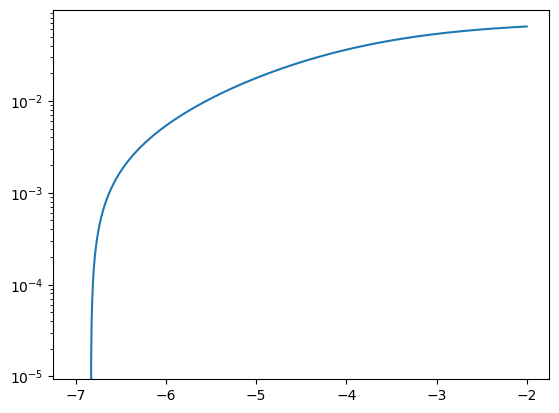

In [4]:
def find_mu_for_dphi(df, k,dmu, dphi_c=0.3):
    solutions = []
    for mu in np.linspace(-7,-2,10000):
        thermos = npa.Thermos(fres=df, dmu=dmu, k=k, method='HOMO')
        dphi = npa.calculate_dphi(mu, thermos)
        if np.isclose(dphi, dphi_c, atol=1e-3):
            solutions.append(mu)
    return np.average(solutions)


find_mu_for_dphi(2.0, 1.0, 2.0, 0.0)


df = 2.0
k = 1.0
dmu = 1.0*np.exp(-2.0)
vs_df2_dmu_2_s6 = []
mu_space_df2_dmu_2_s6 = np.linspace(-7.0,-2.0,1000)
for mu in mu_space_df2_dmu_2_s6:
    vs_df2_dmu_2_s6.append(calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0))


plt.plot(mu_space_df2_dmu_2_s6, vs_df2_dmu_2_s6)
plt.yscale('log')

print(mu_space_df2_dmu_2_s6[np.argwhere(np.array(vs_df2_dmu_2_s6) > 0.0)[0]])

In [5]:
from plot_defaults import *
set_plot_defaults()
whiteout()

Plot defaults set.
Whiteout mode set.


[30]
[-6.07387387]


/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/3753337008.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/3753337008.py:50: RuntimeWarning: invalid value encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]


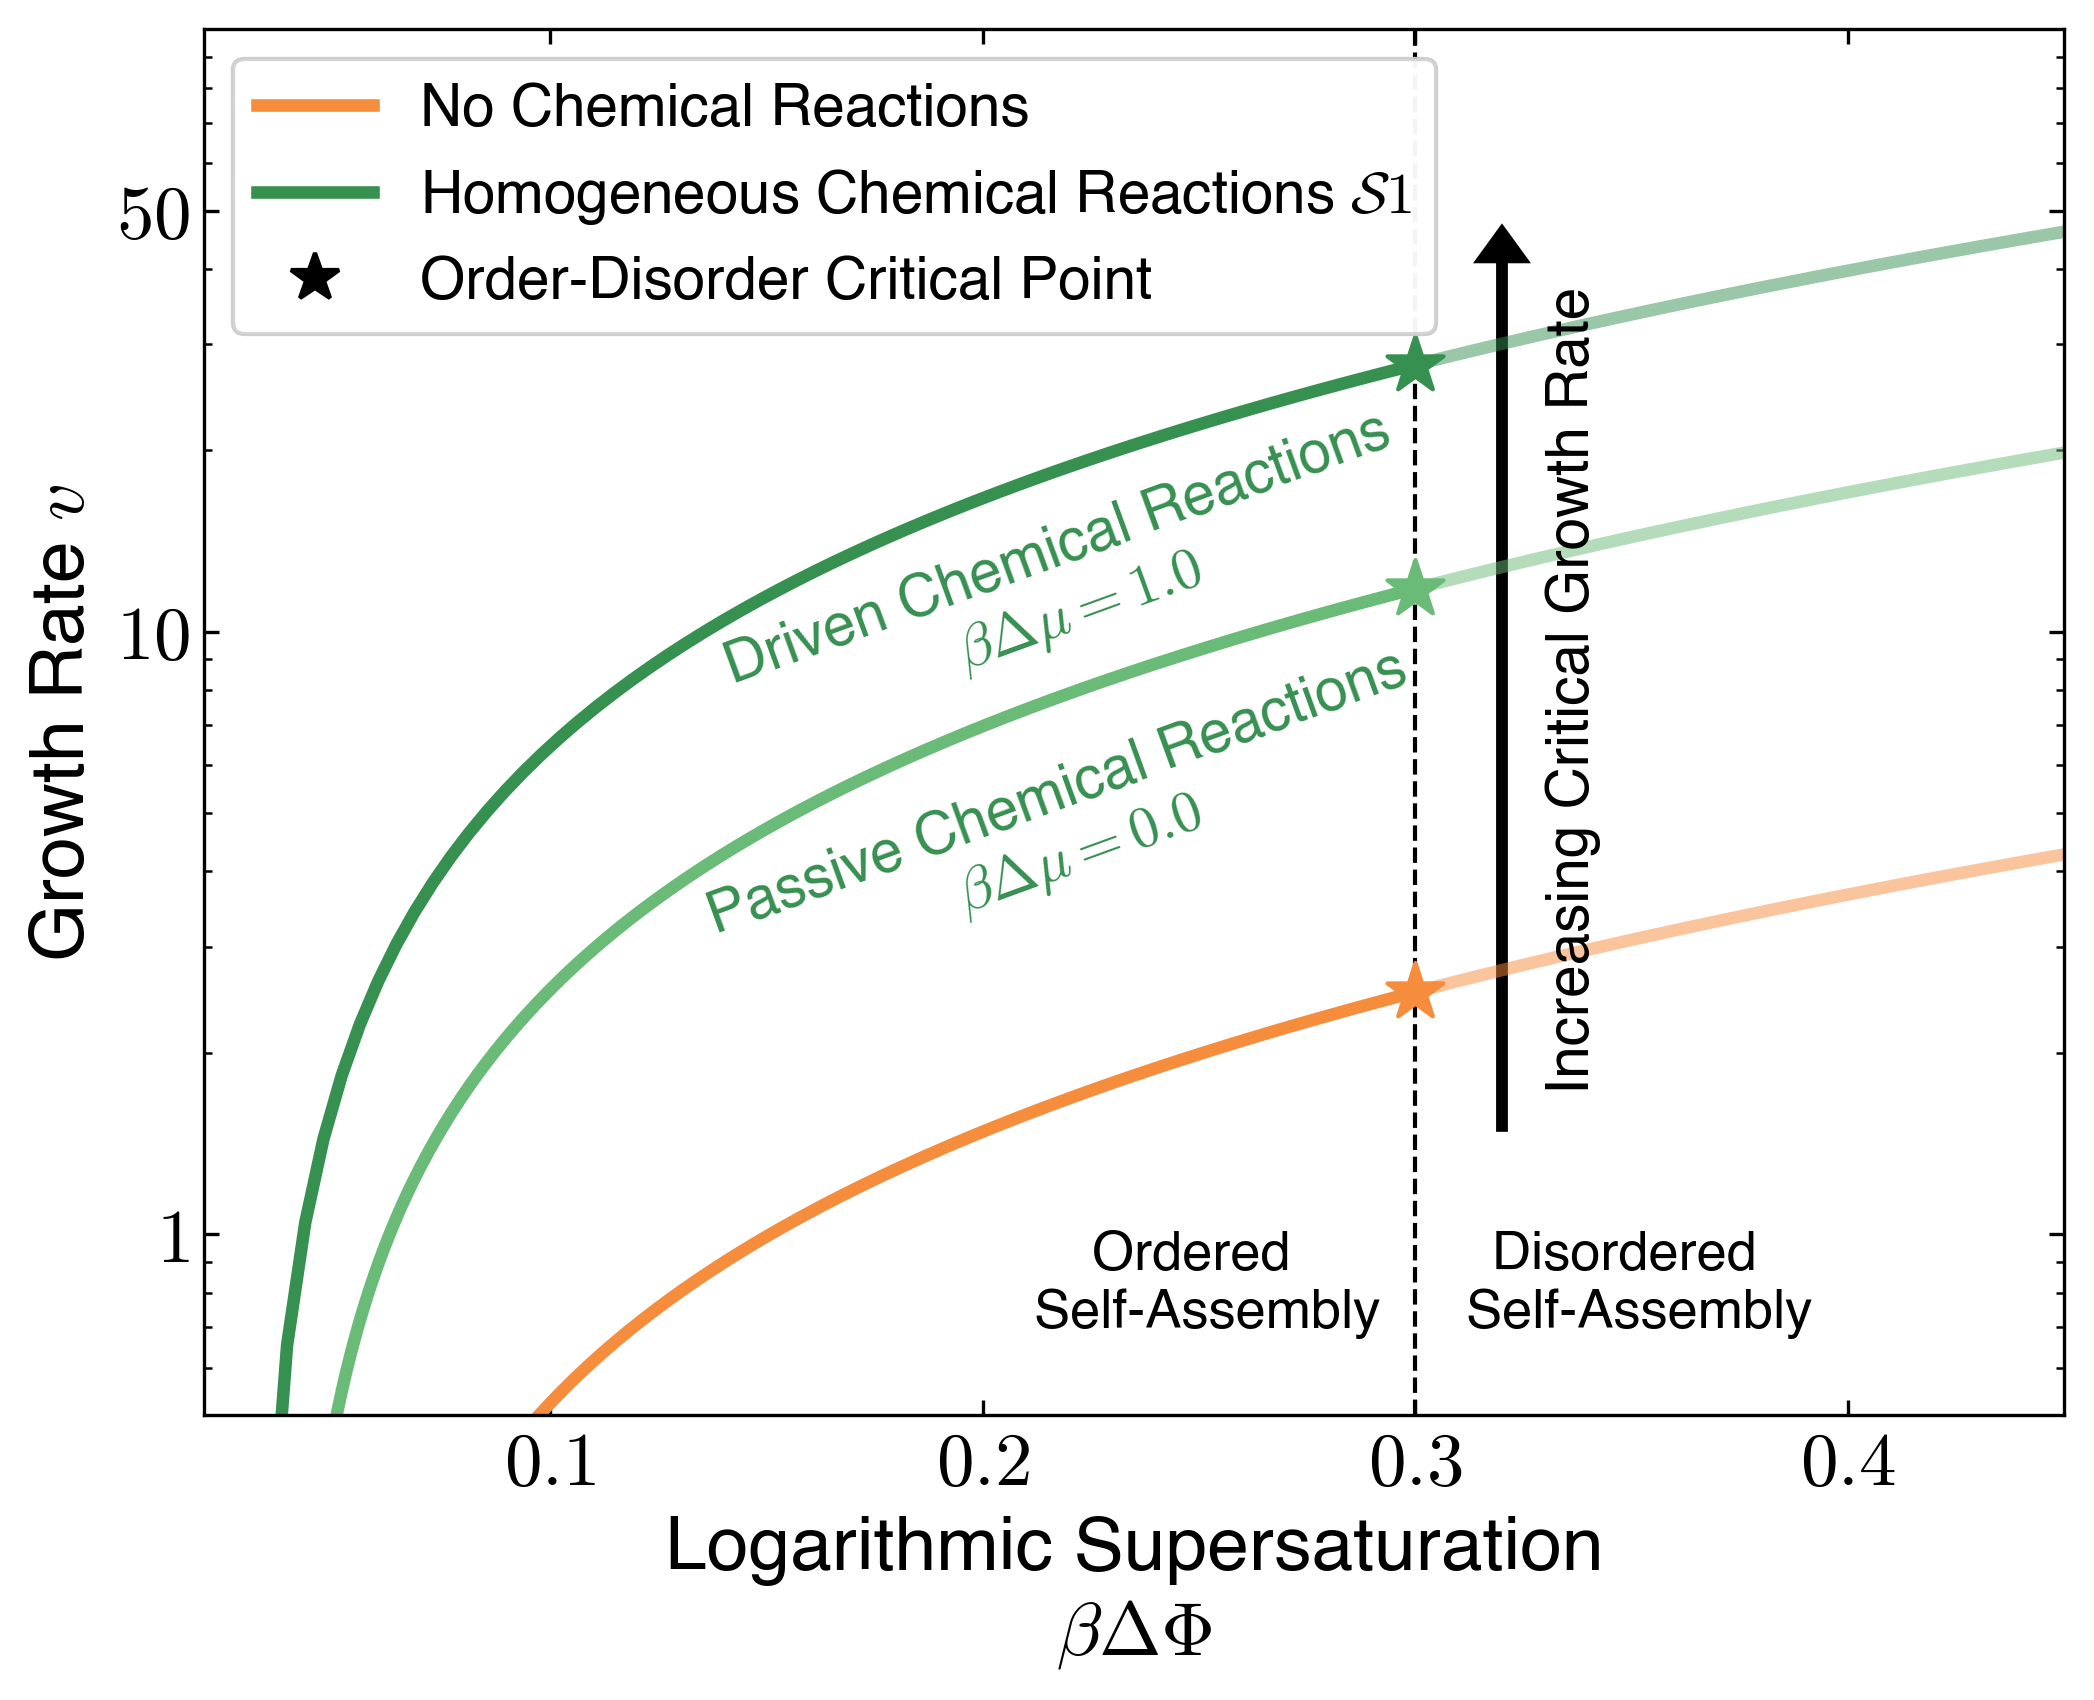

In [6]:
critical_logS = 0.3

df = -20.0
k = 0.0
dmu = 0.0
vs = []
mu_space_eq = np.linspace(-6.99,-6.0,1000)
for mu in mu_space_eq:
    vs.append(calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0))

mu_coex_flex = -6.990
mu_space_eq -= mu_coex_flex



mask_eq = mu_space_eq < 0.3
plt.plot(mu_space_eq[mask_eq], np.array(vs)[mask_eq], label='eq', color=ORANGE, lw=3)
mask_eq = mu_space_eq >= 0.3
plt.plot(mu_space_eq[mask_eq], np.array(vs)[mask_eq], label='eq', linestyle='-', color=ORANGE, lw=3, alpha=0.5)


crit = calc_v_eff_from_flex(k, mu_coex_flex+0.3, df, dmu, -3.5, -2.0)
plt.scatter(0.3, crit, marker='*', color=ORANGE, s=200)

greens = sns.color_palette(palette='Greens_d')

df = 2.0
k = 1.0
dmu = 0.0
vs_df2 = []
mu_space_df2_dmu_0_s6 = np.linspace(-6.95,-6.0,1000)
for mu in mu_space_df2_dmu_0_s6:
    vs_df2.append(calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0))

mu_coex_flex = -6.980
mu_space_df2_dmu_0_s6 -= mu_coex_flex

mask_eq = mu_space_df2_dmu_0_s6 < 0.3
plt.plot(mu_space_df2_dmu_0_s6[mask_eq], np.array(vs_df2)[mask_eq], label='eq', color=greens[1], lw=3)
mask_eq = mu_space_df2_dmu_0_s6 >= 0.3
plt.plot(mu_space_df2_dmu_0_s6[mask_eq], np.array(vs_df2)[mask_eq], label='eq', linestyle='-', color=greens[1], lw=3, alpha=0.5)

crit = calc_v_eff_from_flex(k, mu_coex_flex+0.3, df, dmu, -3.5, -2.0)
plt.scatter(0.3, crit, marker='*', color=greens[1], s=200)

df = 2.0
k = 1.0
dmu = 1.0
vs_df2_dmu_2_s6 = []
mu_space_df2_dmu_2_s6 = np.linspace(-6.2,-2.0,1000)
for mu in mu_space_df2_dmu_2_s6:
    vs_df2_dmu_2_s6.append(calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0))


print(np.argwhere(np.array(vs_df2_dmu_2_s6) > 0.0)[0])
mu_coex_flex = mu_space_df2_dmu_2_s6[np.argwhere(np.array(vs_df2_dmu_2_s6) > 0.0)[0]]
print(mu_coex_flex)
mu_coex_flex = -6.108810881088
mu_space_df2_dmu_2_s6 -= mu_coex_flex


mask_eq = mu_space_df2_dmu_2_s6 < 0.3
plt.plot(mu_space_df2_dmu_2_s6[mask_eq], np.array(vs_df2_dmu_2_s6)[mask_eq], label='eq', color=greens[3], lw=3)
mask_eq = mu_space_df2_dmu_2_s6 >= 0.3
plt.plot(mu_space_df2_dmu_2_s6[mask_eq], np.array(vs_df2_dmu_2_s6)[mask_eq], label='eq', linestyle='-', color=greens[3], lw=3, alpha=0.5)

crit = calc_v_eff_from_flex(k, mu_coex_flex+0.3, df, dmu, -3.5, -2.0)
plt.scatter(0.3, crit, marker='*', color=greens[3], s=200)

vs = np.array(vs)
reference = vs[0]
vs = vs 
vs_df2 = np.array(vs_df2) 
vs_df2_dmu_2_s6 = np.array(vs_df2_dmu_2_s6)
plt.yscale('log')

plt.xlim(0.02, 0.45)
plt.ylim(5e-5, 1e-2)

plt.yticks([1e-4, 1e-3, 5e-3], labels=[r'$1$', r'$10$', r'$50$'], fontsize=FS_LEGEND)
plt.xticks([0.1, 0.2, 0.3, 0.4], labels=[r'$0.1$', r'$0.2$', r'$0.3$', r'$0.4$'], fontsize=FS_LEGEND)
# plt.axvline(0.3, color='k', ls='--')

plt.arrow(0.32, 1.5e-4, 0, 4e-3, color='k', lw=1.8, head_width=0.01, head_length=5e-4)
plt.text(0.33, 0.8e-3, 'Increasing Critical Growth Rate', fontsize=FS_LEGEND-4, rotation=90, va='center', zorder=100)


plt.text(0.22, 0.25e-3, r'Passive Chemical Reactions' + '\n' + r'$\beta \Delta \mu = 0.0$', fontsize=FS_LEGEND-4, ha='center', color=greens[3], rotation=20)

plt.text(0.22, 0.65e-3, r'Driven Chemical Reactions' + '\n' + r'$\beta \Delta \mu = 1.0$', fontsize=FS_LEGEND-4, ha='center', color=greens[3], rotation=20)

plt.xlabel(r"Logarithmic Supersaturation" + "\n" + r"$\beta \Delta \Phi$")
plt.ylabel(r"Growth Rate $v$")


plt.text(0.35, 0.7e-4, "Disordered \n Self-Assembly", fontsize=FS_LEGEND-5, ha='center', color='k', rotation=0)
plt.text(0.25, 0.7e-4, "Ordered \n Self-Assembly", fontsize=FS_LEGEND-5, ha='center', color='k', rotation=0)

plt.axvline(0.3, color='k', ls='--', lw=1, zorder=-5)

ax = plt.gca()

from matplotlib.lines import Line2D

condition_handles = [
    Line2D([0], [0], color=ORANGE, lw=3, label=r"No Chemical Reactions"),
    Line2D([0], [0], color=greens[3], lw=3, label=r"Homogeneous Chemical Reactions $\mathcal{S}1$"),
    Line2D([0], [0], marker="*", color="k", lw=0, markersize=12, label=rf"Order-Disorder Critical Point"),
]


leg1 = ax.legend(handles=condition_handles, fontsize=FS_LEGEND - 4, loc="upper left", frameon=True)
ax.add_artist(leg1)


In [7]:
from scipy import interpolate as slines

/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/3753337008.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/3753337008.py:50: RuntimeWarning: invalid value encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]


[30]
[-6.07387387]
0.007061720894132884


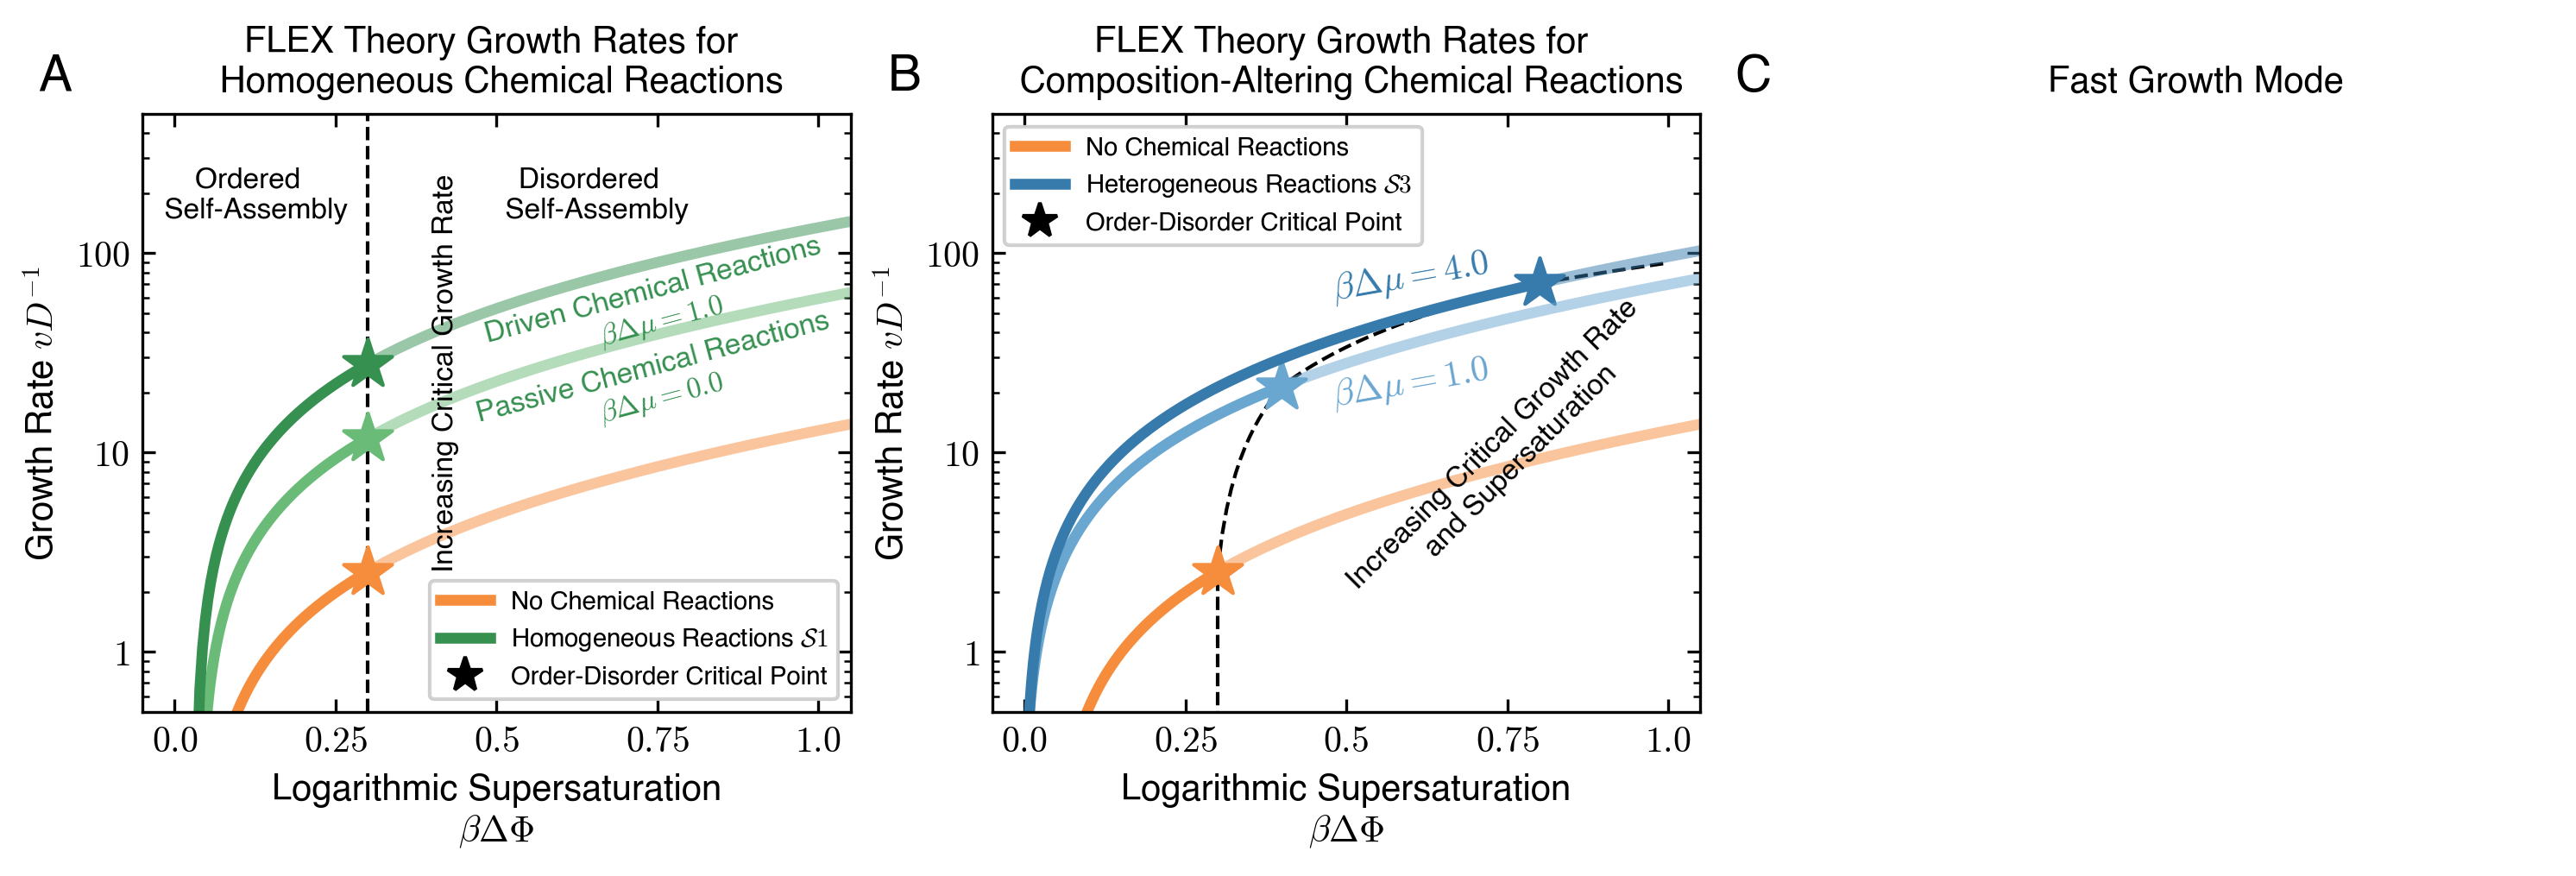

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
FS_LEGEND = 10

spline_x_vals = []
spline_y_vals = []

spline_x_vals.append(0.3)
spline_y_vals.append(1e-6)


critical_logS = 0.3

df = -20.0
k = 0.0
dmu = 0.0
vs = []
mu_space_eq = np.linspace(-6.99,-5.0,2000)
for mu in mu_space_eq:
    vs.append(calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0))

mu_coex_flex = -6.990
mu_space_eq -= mu_coex_flex



mask_eq = mu_space_eq < 0.3
axes[0].plot(mu_space_eq[mask_eq], np.array(vs)[mask_eq], label='eq', color=ORANGE, lw=3)
axes[1].plot(mu_space_eq[mask_eq], np.array(vs)[mask_eq], label='eq', color=ORANGE, lw=3)

mask_eq = mu_space_eq >= 0.3
axes[0].plot(mu_space_eq[mask_eq], np.array(vs)[mask_eq], label='eq', linestyle='-', color=ORANGE, lw=3, alpha=0.5)
axes[1].plot(mu_space_eq[mask_eq], np.array(vs)[mask_eq], label='eq', linestyle='-', color=ORANGE, lw=3, alpha=0.5)


crit = calc_v_eff_from_flex(k, mu_coex_flex+0.3, df, dmu, -3.5, -2.0)
axes[0].scatter(0.3, crit, marker='*', color=ORANGE, s=200)
axes[1].scatter(0.3, crit, marker='*', color=ORANGE, s=200)

spline_x_vals.append(0.3)
spline_y_vals.append(crit)
crit_eq = crit
greens = sns.color_palette(palette='Greens_d')

df = 2.0
k = 1.0
dmu = 0.0
vs_df2 = []
mu_space_df2_dmu_0_s6 = np.linspace(-6.95,-5.0,2000)
for mu in mu_space_df2_dmu_0_s6:
    vs_df2.append(calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0))

mu_coex_flex = -6.980
mu_space_df2_dmu_0_s6 -= mu_coex_flex

mask_eq = mu_space_df2_dmu_0_s6 < 0.3
axes[0].plot(mu_space_df2_dmu_0_s6[mask_eq], np.array(vs_df2)[mask_eq], label='eq', color=greens[1], lw=3)
mask_eq = mu_space_df2_dmu_0_s6 >= 0.3
axes[0].plot(mu_space_df2_dmu_0_s6[mask_eq], np.array(vs_df2)[mask_eq], label='eq', linestyle='-', color=greens[1], lw=3, alpha=0.5)

crit = calc_v_eff_from_flex(k, mu_coex_flex+0.3, df, dmu, -3.5, -2.0)
axes[0].scatter(0.3, crit, marker='*', color=greens[1], s=200)

df = 2.0
k = 1.0
dmu = 1.0
vs_df2_dmu_2_s6 = []
mu_space_df2_dmu_2_s6 = np.linspace(-6.2,-2.0,1000)
for mu in mu_space_df2_dmu_2_s6:
    vs_df2_dmu_2_s6.append(calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0))


print(np.argwhere(np.array(vs_df2_dmu_2_s6) > 0.0)[0])
mu_coex_flex = mu_space_df2_dmu_2_s6[np.argwhere(np.array(vs_df2_dmu_2_s6) > 0.0)[0]]
print(mu_coex_flex)
mu_coex_flex = -6.108810881088
mu_space_df2_dmu_2_s6 -= mu_coex_flex


mask_eq = mu_space_df2_dmu_2_s6 < 0.3
axes[0].plot(mu_space_df2_dmu_2_s6[mask_eq], np.array(vs_df2_dmu_2_s6)[mask_eq], label='eq', color=greens[3], lw=3)
mask_eq = mu_space_df2_dmu_2_s6 >= 0.3
axes[0].plot(mu_space_df2_dmu_2_s6[mask_eq], np.array(vs_df2_dmu_2_s6)[mask_eq], label='eq', linestyle='-', color=greens[3], lw=3, alpha=0.5)

crit = calc_v_eff_from_flex(k, mu_coex_flex+0.3, df, dmu, -3.5, -2.0)
axes[0].scatter(0.3, crit, marker='*', color=greens[3], s=200)

vs = np.array(vs)
reference = vs[0]
vs = vs 
vs_df2 = np.array(vs_df2) 
vs_df2_dmu_2_s6 = np.array(vs_df2_dmu_2_s6)
axes[0].set_yscale('log')

axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(5e-5, 5e-2)

axes[0].set_yticks([1e-4, 1e-3, 1e-2], labels=[r'$1$', r'$10$', r'$100$'], fontsize=FS_LEGEND)
# axes[0].set_xticks([0.0, 0.1, 0.2, 0.3, 0.4], labels=[r'$0.0$', r'$0.1$', r'$0.2$', r'$0.3$', r'$0.4$'], fontsize=FS_LEGEND)
axes[0].set_xticks([0.0, 0.25, 0.5, 0.75, 1.0], labels=[r'$0.0$', r'$0.25$', r'$0.5$', r'$0.75$', r'$1.0$'], fontsize=FS_LEGEND)

# axes[0].axvline(0.3, color='k', ls='--')

# axes[0].arrow(0.37, 1.5e-4, 0, 1.2e-2, color='k', lw=1.8, head_width=0.01, head_length=5e-4)
axes[0].text(0.4, 2.5e-3, 'Increasing Critical Growth Rate', fontsize=FS_LEGEND-2, rotation=90, va='center', zorder=100)




axes[0].set_xlabel(r"Logarithmic Supersaturation" + "\n" + r"$\beta \Delta \Phi$", fontsize=FS_LEGEND)
axes[0].set_ylabel(r"Growth Rate $vD^{-1}$", fontsize=FS_LEGEND)


axes[0].text(0.12, 1.5e-2, "Ordered \n Self-Assembly", fontsize=FS_LEGEND-2, ha='center', color='k', rotation=0)
axes[0].text(0.65, 1.5e-2, "Disordered \n Self-Assembly", fontsize=FS_LEGEND-2, ha='center', color='k', rotation=0)

axes[0].axvline(0.3, color='k', ls='--', lw=1, zorder=-5)

from matplotlib.lines import Line2D

condition_handles = [
    Line2D([0], [0], color=ORANGE, lw=3, label=r"No Chemical Reactions"),
    Line2D([0], [0], color=greens[3], lw=3, label=r"Homogeneous Reactions $\mathcal{S}1$"),
    Line2D([0], [0], marker="*", color="k", lw=0, markersize=10, label=rf"Order-Disorder Critical Point"),
]
leg1 = axes[0].legend(handles=condition_handles, fontsize=FS_LEGEND - 3, loc="lower right", frameon=True)
axes[0].add_artist(leg1)


# Second Plot


blues = sns.color_palette(palette='Blues_d')

df = 2.0
k = 1.0
dmu = np.exp(-2.0)*1.0
vs_df2 = []
mu_space_df2_dmu_0_s6 = np.linspace(-7,-5.0,1000)
for mu in mu_space_df2_dmu_0_s6:
    vs_df2.append(calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0))

mu_coex_flex = -6.82982983
mu_space_df2_dmu_0_s6 -= mu_coex_flex

mask_eq = mu_space_df2_dmu_0_s6 < 0.4
axes[1].plot(mu_space_df2_dmu_0_s6[mask_eq], np.array(vs_df2)[mask_eq], label='eq', color=blues[1], lw=3)
mask_eq = mu_space_df2_dmu_0_s6 >= 0.4
axes[1].plot(mu_space_df2_dmu_0_s6[mask_eq], np.array(vs_df2)[mask_eq], label='eq', linestyle='-', color=blues[1], lw=3, alpha=0.5)

crit = calc_v_eff_from_flex(k, mu_coex_flex+0.4, df, dmu, -3.5, -2.0)
axes[1].scatter(0.4, crit, marker='*', color=blues[1], s=200)

spline_x_vals.append(0.4)
spline_y_vals.append(crit)

df = 2.0
k = 1.0
dmu = 4.0*np.exp(-2.0)
vs_df2_dmu_2_s6 = []
mu_space_df2_dmu_2_s6 = np.linspace(-7,-5.0,1000)
for mu in mu_space_df2_dmu_2_s6:
    vs_df2_dmu_2_s6.append(calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0))


mu_coex_flex = -6.48948949
mu_space_df2_dmu_2_s6 -= mu_coex_flex


mask_eq = mu_space_df2_dmu_2_s6 < 0.8
axes[1].plot(mu_space_df2_dmu_2_s6[mask_eq], np.array(vs_df2_dmu_2_s6)[mask_eq], label='eq', color=blues[3], lw=3)
mask_eq = mu_space_df2_dmu_2_s6 >= 0.8
axes[1].plot(mu_space_df2_dmu_2_s6[mask_eq], np.array(vs_df2_dmu_2_s6)[mask_eq], label='eq', linestyle='-', color=blues[3], lw=3, alpha=0.5)

crit = calc_v_eff_from_flex(k, mu_coex_flex+0.8, df, dmu, -3.5, -2.0)
axes[1].scatter(0.8, crit, marker='*', color=blues[3], s=200)

spline_x_vals.append(0.8)
spline_y_vals.append(crit)
print(crit)
spline_x_vals.append(1.1)
spline_y_vals.append(crit*1.4)

vs = np.array(vs)
reference = vs[0]
vs = vs 
vs_df2 = np.array(vs_df2) 
vs_df2_dmu_2_s6 = np.array(vs_df2_dmu_2_s6)
axes[1].set_yscale('log')

axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(5e-5, 5e-2)

axes[1].set_yticks([1e-4, 1e-3, 1e-2], labels=[r'$1$', r'$10$', r'$100$'], fontsize=FS_LEGEND)
axes[1].set_xticks([0.0, 0.25, 0.5, 0.75, 1.0], labels=[r'$0.0$', r'$0.25$', r'$0.5$', r'$0.75$', r'$1.0$'], fontsize=FS_LEGEND)
# axes[1].axvline(0.3, color='k', ls='--')




axes[1].set_xlabel(r"Logarithmic Supersaturation" + "\n" + r"$\beta \Delta \Phi$", fontsize=FS_LEGEND)
axes[1].set_ylabel(r"Growth Rate $vD^{-1}$", fontsize=FS_LEGEND)


# axes[1].text(0.35, 0.7e-4, "Disordered \n Self-Assembly", fontsize=FS_LEGEND-5, ha='center', color='k', rotation=0)
# axes[1].text(0.25, 0.7e-4, "Ordered \n Self-Assembly", fontsize=FS_LEGEND-5, ha='center', color='k', rotation=0)


from matplotlib.lines import Line2D

condition_handles = [
    Line2D([0], [0], color=ORANGE, lw=3, label=r"No Chemical Reactions"),
    Line2D([0], [0], color=blues[3], lw=3, label=r"Heterogeneous Reactions $\mathcal{S}3$"),
    Line2D([0], [0], marker="*", color="k", lw=0, markersize=10, label=rf"Order-Disorder Critical Point"),
]
leg1 = axes[1].legend(handles=condition_handles, fontsize=FS_LEGEND - 3, loc="upper left", frameon=True)
axes[1].add_artist(leg1)


axes[0].text(0.75, 1.0e-3, r'Passive Chemical Reactions' + '\n' + r'$\beta \Delta \mu = 0.0$', fontsize=FS_LEGEND-2, ha='center', color=greens[3], rotation=15)
axes[0].text(0.75, 2.5e-3, r'Driven Chemical Reactions' + '\n' + r'$\beta \Delta \mu = 1.0$', fontsize=FS_LEGEND-2, ha='center', color=greens[3], rotation=15)

axes[1].text(0.6, 1.7e-3, r'$\beta \Delta \mu = 1.0$', fontsize=FS_LEGEND, ha='center', color=blues[1], rotation=10)
axes[1].text(0.6, 5.8e-3, r'$\beta \Delta \mu = 4.0$', fontsize=FS_LEGEND, ha='center', color=blues[3], rotation=10)

splines = slines.interp1d(spline_x_vals, spline_y_vals)
x_spline = np.linspace(0.3, 1.0, 100)
y_spline = splines(x_spline)
axes[1].plot(x_spline, y_spline, color='k', lw=1, ls='--', zorder=0)
axes[1].plot([0.3,0.3], [1e-6, crit_eq], color='k', lw=1, ls='--', zorder=0)

for spines in axes[2].spines.values():
    spines.set_visible(False)
axes[2].set_xticks([])
axes[2].set_yticks([])

axes[0].text(
    -0.1,
    1.1,
    "A",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
)

axes[1].text(
    -0.1,
    1.1,
    "B",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
)

axes[2].text(
    -0.1,
    1.1,
    "C",
    transform=axes[2].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
)


# axes[1].arrow(0.37, 1.5e-4, 0.45, 1.2e-2, color='k')
axes[1].text(0.75, 1e-3, 'Increasing Critical Growth Rate \n and Supersaturation', fontsize=FS_LEGEND-2, rotation=45, va='center', zorder=100, ha='center')

axes[2].set_title('Fast Growth Mode', fontsize=FS_LEGEND)
axes[0].set_title('FLEX Theory Growth Rates for \n Homogeneous Chemical Reactions', fontsize=FS_LEGEND)
axes[1].set_title('FLEX Theory Growth Rates for \n Composition-Altering Chemical Reactions', fontsize=FS_LEGEND)

plt.savefig('speed_conceptual_figure.pdf', dpi=300, bbox_inches='tight')

In [9]:
from plot_defaults import *
set_plot_defaults()
whiteout()

blues = sns.color_palette(palette='Blues_d')
reds = sns.color_palette(palette='Reds_d')
greens = sns.color_palette(palette='Greens_d')
purples = sns.color_palette(palette='Purples_d')
oranges = sns.color_palette(palette='Oranges_d')

Plot defaults set.
Whiteout mode set.


INFO:root:Initialized DynamicalOrderDisorder analysis for reference with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for f2d0s1 with 13 CSV files


           m        dm    mu             t            dt   df    k        m2  \
0   0.989996  0.000604 -6.90  1.179979e+06  11012.348255  2.0  1.0  0.980101   
1   0.981604  0.002173 -6.85  4.933157e+05  39803.673685  2.0  1.0  0.963619   
2   0.943743  0.008011 -6.80  2.792675e+05   1450.238818  2.0  1.0  0.893154   
3   0.812911  0.030660 -6.75  2.148030e+05   1210.227915  2.0  1.0  0.697484   
4   0.622907  0.044571 -6.70  1.685401e+05    965.836542  2.0  1.0  0.449597   
5   0.430763  0.041046 -6.65  1.375512e+05   1116.779878  2.0  1.0  0.237785   
6   0.291558  0.029817 -6.60  1.132980e+05    607.096009  2.0  1.0  0.119678   
7   0.195127  0.025059 -6.55  9.458739e+04    563.858762  2.0  1.0  0.062564   
8   0.148958  0.016787 -6.50  7.776711e+04    644.722744  2.0  1.0  0.033179   
9   0.097616  0.011784 -6.45  6.534176e+04    518.573383  2.0  1.0  0.014807   
10  0.092172  0.012186 -6.40  5.400529e+04    445.229699  2.0  1.0  0.014287   
11  0.075472  0.010146 -6.35  4.444190e+

INFO:root:Initialized DynamicalOrderDisorder analysis for f2d2s1 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for f2d0s6 with 10 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for f2d2s6 with 9 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for f0_0.001 with 2 CSV files
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:201: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:204: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
INFO:root:Initialized DynamicalOrderDisorder analysis

 df = 0.0
0.09762747162843302
 df = 0.0
0.09762747162843302


/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:201: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:204: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
INFO:root:Initialized DynamicalOrderDisorder analysis for f0_1.0 with 13 CSV files
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:201: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / r

...

 df = 2.0
0.08489374227414255
 df = 2.0
0.0848937422741441
 df = 2.0
0.08489374227414322
 df = 2.0
0.0848937422741441


/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:257: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:260: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
INFO:root:Initialized DynamicalOrderDisorder analysis for f4_0.01 with 3 CSV files
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:303: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / r

 df = 4.0
0.08482449600551785
 df = 4.0
0.08482449600551709
 df = 4.0
0.08482449600551709


INFO:root:Initialized DynamicalOrderDisorder analysis for f4_10.0 with 13 CSV files
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:303: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/4224805742.py:307: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])


 df = 4.0
0.0848244960055162


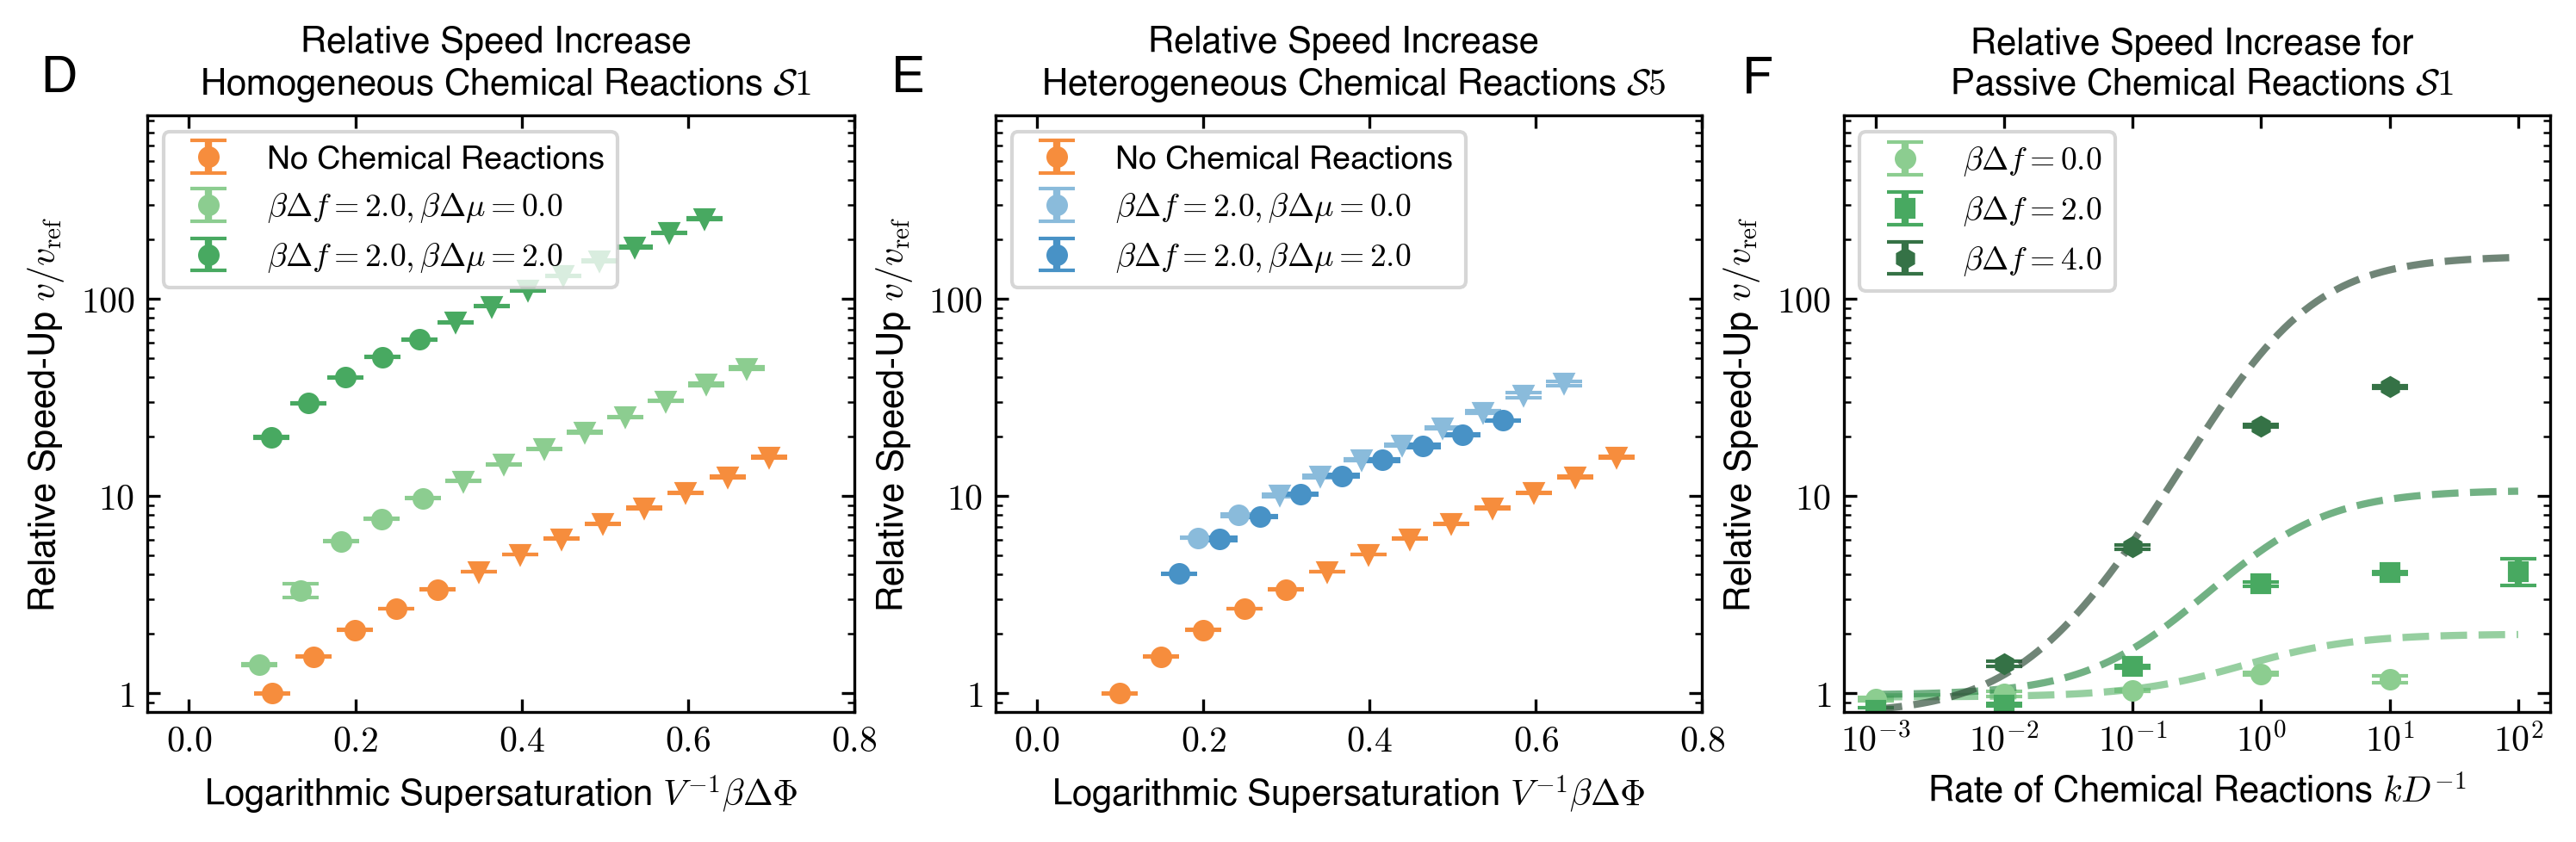

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
FS_LEGEND = 10

sites = 2 *80**2

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_BASELINE")
analysis = npa.DynamicalOrderDisorder("reference", base_path)
thermos = npa.Thermos(fres=-20.0, k=0)
no_chemical_reactions_numerical = analysis.get_data()
no_chemical_reactions_numerical["dphi"] = npa.calculate_dphi(no_chemical_reactions_numerical["mu"], thermos)
no_chemical_reactions_numerical = no_chemical_reactions_numerical.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
baseline_speed = no_chemical_reactions_numerical["growth_speed"].min()
no_chemical_reactions_numerical["growth_speed"] = no_chemical_reactions_numerical["growth_speed"] / baseline_speed
no_chemical_reactions_numerical["delta_growth_speed"] = no_chemical_reactions_numerical["delta_growth_speed"] / baseline_speed

axes[0].errorbar(no_chemical_reactions_numerical["dphi"][no_chemical_reactions_numerical["m"] > 0.5], no_chemical_reactions_numerical["growth_speed"][no_chemical_reactions_numerical["m"] > 0.5],yerr=no_chemical_reactions_numerical['delta_growth_speed'][no_chemical_reactions_numerical["m"] > 0.5], lw=0, label='No Chemical Reactions', color=ORANGE,
                 ms=5, marker='o', capsize=5, elinewidth=2)

axes[1].errorbar(no_chemical_reactions_numerical["dphi"][no_chemical_reactions_numerical["m"] > 0.5], no_chemical_reactions_numerical["growth_speed"][no_chemical_reactions_numerical["m"] > 0.5],yerr=no_chemical_reactions_numerical['delta_growth_speed'][no_chemical_reactions_numerical["m"] > 0.5], lw=0, label='No Chemical Reactions', color=ORANGE,
                 ms=5, marker='o', capsize=5, elinewidth=2)


axes[0].errorbar(no_chemical_reactions_numerical["dphi"][no_chemical_reactions_numerical["m"] < 0.5], no_chemical_reactions_numerical["growth_speed"][no_chemical_reactions_numerical["m"] < 0.5],yerr=no_chemical_reactions_numerical['delta_growth_speed'][no_chemical_reactions_numerical["m"] < 0.5], lw=0, color=ORANGE,
                 ms=5, marker='v', capsize=5, elinewidth=2)

axes[1].errorbar(no_chemical_reactions_numerical["dphi"][no_chemical_reactions_numerical["m"] < 0.5], no_chemical_reactions_numerical["growth_speed"][no_chemical_reactions_numerical["m"] < 0.5],yerr=no_chemical_reactions_numerical['delta_growth_speed'][no_chemical_reactions_numerical["m"] < 0.5], lw=0, color=ORANGE,
                 ms=5, marker='v', capsize=5, elinewidth=2)


############### LEFT PLOT ###############
# for S1: greens

colors = sns.color_palette(palette='Greens_d')

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D0_K1")
analysis = npa.DynamicalOrderDisorder("f2d0s1", base_path)
thermos = npa.Thermos(fres=2.0, k=1.0)
f2d0s1 = analysis.get_data()
f2d0s1["dphi"] = npa.calculate_dphi(f2d0s1["mu"], thermos)
f2d0s1 = f2d0s1.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
f2d0s1["growth_speed"] = f2d0s1["growth_speed"] / baseline_speed
f2d0s1["delta_growth_speed"] = f2d0s1["delta_growth_speed"] / baseline_speed

print(f2d0s1)

axes[0].errorbar(f2d0s1["dphi"][f2d0s1["m"] > 0.5], f2d0s1["growth_speed"][f2d0s1["m"] > 0.5],yerr=f2d0s1['delta_growth_speed'][f2d0s1["m"] > 0.5], lw=0, label=r'$\beta \Delta f = 2.0, \beta \Delta \mu = 0.0$', color=colors[0],
                 ms=5, marker='o', capsize=5, elinewidth=2)

axes[0].errorbar(f2d0s1["dphi"][f2d0s1["m"] < 0.5], f2d0s1["growth_speed"][f2d0s1["m"] < 0.5],yerr=f2d0s1['delta_growth_speed'][f2d0s1["m"] < 0.5], lw=0, color=colors[0],
                 ms=5, marker='v', capsize=5, elinewidth=2)

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D2_K1")
analysis = npa.DynamicalOrderDisorder("f2d2s1", base_path)
thermos = npa.Thermos(fres=2.0, k=1.0, dmu=2.0, method='HOMO')
f2d2s1 = analysis.get_data()
f2d2s1["dphi"] = npa.calculate_dphi(f2d2s1["mu"], thermos)
f2d2s1 = f2d2s1.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
f2d2s1["growth_speed"] = f2d2s1["growth_speed"] / baseline_speed
f2d2s1["delta_growth_speed"] = f2d2s1["delta_growth_speed"] / baseline_speed

axes[0].errorbar(f2d2s1["dphi"][f2d2s1["m"] > 0.5], f2d2s1["growth_speed"][f2d2s1["m"] > 0.5],yerr=f2d2s1['delta_growth_speed'][f2d2s1["m"] > 0.5], lw=0, color=colors[2],
                 ms=5, marker='o', capsize=5, elinewidth=2, label=r"$\beta \Delta f = 2.0, \beta \Delta \mu = 2.0$")

axes[0].errorbar(f2d2s1["dphi"][f2d2s1["m"] < 0.5], f2d2s1["growth_speed"][f2d2s1["m"] < 0.5],yerr=f2d2s1['delta_growth_speed'][f2d2s1["m"] < 0.5], lw=0, color=colors[2],
                 ms=5, marker='v', capsize=5, elinewidth=2)



axes[0].set_title('Relative Speed Increase \n Homogeneous Chemical Reactions' + r" $\mathcal{S}1$", fontsize=FS_LEGEND)




############### MIDDLE PLOT ###############
# for S6: blues

colors = sns.color_palette(palette='Blues_d')

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D0_K1_SCHEME6")
analysis = npa.DynamicalOrderDisorder("f2d0s6", base_path)
thermos = npa.Thermos(fres=2.0, k=1.0, method='SCHEME6', dmu=0.0)
f2d0s6 = analysis.get_data()
f2d0s6["dphi"] = npa.calculate_dphi(f2d0s6["mu"], thermos)
f2d0s6 = f2d0s6.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
f2d0s6["growth_speed"] = f2d0s6["growth_speed"] / baseline_speed
f2d0s6["delta_growth_speed"] = f2d0s6["delta_growth_speed"] / baseline_speed

axes[1].errorbar(f2d0s6["dphi"][f2d0s6["m"] < 0.5], f2d0s6["growth_speed"][f2d0s6["m"] < 0.5],yerr=f2d0s6['delta_growth_speed'][f2d0s6["m"] < 0.5], lw=0, color=colors[0],
                 ms=5, marker='v', capsize=5, elinewidth=2)

axes[1].errorbar(f2d0s6["dphi"][f2d0s6["m"] > 0.5], f2d0s6["growth_speed"][f2d0s6["m"] > 0.5],yerr=f2d0s6['delta_growth_speed'][f2d0s6["m"] > 0.5], lw=0, color=colors[0],
                 ms=5, marker='o', capsize=5, elinewidth=2, label=r'$\beta \Delta f = 2.0, \beta \Delta \mu = 0.0$')

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D2_K1_SCHEME6")
analysis = npa.DynamicalOrderDisorder("f2d2s6", base_path)
thermos = npa.Thermos(fres=2.0, k=1.0, dmu=2.0, method='SCHEME6')
f2d2s6 = analysis.get_data()
f2d2s6["dphi"] = npa.calculate_dphi(f2d2s6["mu"], thermos)
f2d2s6 = f2d2s6.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
f2d2s6["growth_speed"] = f2d2s6["growth_speed"] / baseline_speed
f2d2s6["delta_growth_speed"] = f2d2s6["delta_growth_speed"] / baseline_speed

axes[1].errorbar(f2d2s6["dphi"][f2d2s6["m"] < 0.5], f2d2s6["growth_speed"][f2d2s6["m"] < 0.5],yerr=f2d2s6['delta_growth_speed'][f2d2s6["m"] < 0.5], lw=0, color=colors[2],
                 ms=5, marker='^', capsize=5, elinewidth=2)

axes[1].errorbar(f2d2s6["dphi"][f2d2s6["m"] > 0.5], f2d2s6["growth_speed"][f2d2s6["m"] > 0.5],yerr=f2d2s6['delta_growth_speed'][f2d2s6["m"] > 0.5], lw=0, color=colors[2],
                 ms=5, marker='o', capsize=5, elinewidth=2, label=r"$\beta \Delta f = 2.0, \beta \Delta \mu = 2.0$")




axes[1].set_title('Relative Speed Increase \n Heterogeneous Chemical Reactions' + r" $\mathcal{S}5$", fontsize=FS_LEGEND)





for i in [0,1]:

    axes[i].set_yscale("log")
    axes[i].set_yticks(
        [1, 10, 100], [r"$1$", r"$10$", r"$100$"], fontsize=FS_LEGEND
    )
    axes[i].set_ylim(0.8, 850)
    axes[i].set_ylabel(r"Relative Speed-Up $v / v_\mathrm{ref}$", fontsize=FS_LEGEND)

    axes[i].legend(fontsize=FS_LEGEND - 5)

    axes[i].set_xticks(
        [0.0, 0.2, 0.4, 0.6, 0.8],
        [r"$0.0$", r"$0.2$", r"$0.4$", r"$0.6$", r"$0.8$"],
        fontsize=FS_LEGEND,
    )
    axes[i].set_xlim(-0.05, 0.8)
    axes[i].set_xlabel(r"Logarithmic Supersaturation $V^{-1}\beta \Delta \Phi$", fontsize=FS_LEGEND)
    axes[i].legend(fontsize=FS_LEGEND - 1, loc='upper left')



# The right plot



colors = sns.color_palette(palette='Greens_d')


sites = 2 * 40**2

# df = 0.0

# k = np.array([0.001, 0.01, 0.1, 1.0, 10.0, 100.0])
# axes[2].errorbar(
#     k,
#     np.ones_like(k),
#     label=r"No Inactive States",
#     color=ORANGE,
#     ms=8,
#     marker="o",
#     ls="none",
#     capsize=8,
#     alpha=0.7,
#     zorder=0,
# )


rates = [0.001, 0.01, 0.1, 1.0, 10.0]
files = [
    Path("/Volumes/2025/2026/40_160_DFS/F0_K0001"),
    Path("/Volumes/2025/2026/40_160_DFS/F0_K001"),
    Path("/Volumes/2025/2026/40_160_DFS/F0_K01"),
    Path("/Volumes/2025/2026/40_160_DFS/F0_K1"),
    Path("/Volumes/2025/2026/40_160_DFS/F0_K10"),
]

dic = {"k": [], "speed": [], "yerr": []}
for k, f in zip(rates, files):
    analysis = npa.DynamicalOrderDisorder(f"f0_{k}", f)
    thermos = npa.Thermos(fres=0.0, k=k)
    data_k = analysis.get_data()
    data_k["dphi"] = npa.calculate_dphi(data_k["mu"], thermos)
    # print(data_k["dphi"].min())
    time = data_k["t"][data_k["dphi"] == data_k["dphi"].min()]
    # speed = float(1./time)
    # yerr = float(1./(data_k["dt"][data_k["dphi"] == data_k["dphi"].min()])/time**2)

    # speed /= ref_time
    # speed *= sites
    # yerr /= ref_time

    speed = (
        float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
    )
    yerr = (
        float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
        / ref_time
    )

    print(" df = 0.0")
    print(data_k["dphi"].min())

    dic["k"].append(k)
    dic["speed"].append(speed)
    dic["yerr"].append(yerr)

axes[2].errorbar(
    dic["k"],
    dic["speed"],
    yerr=dic["yerr"],
    label=r"$\beta \Delta f = 0.0$",
    color=colors[0],
    ms=5, marker='o', capsize=5, elinewidth=2,
    lw=0
)
# axes[2].errorbar(dic['k'], dic['speed'], yerr=dic['yerr'], fmt='o', color=blues[0], label="df0")


# df = 2.0

rates = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
files = [
    Path("/Volumes/2025/2026/40_160_DFS/F2_K0001"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K001"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K01"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K1"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K10"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K100"),
]

dic = {"k": [], "speed": [], "yerr": []}
for k, f in zip(rates, files):
    analysis = npa.DynamicalOrderDisorder(f"f2_{k}", f)
    thermos = npa.Thermos(fres=2.0, k=k)
    data_k = analysis.get_data()
    data_k["dphi"] = npa.calculate_dphi(data_k["mu"], thermos)
    time = data_k["t"][data_k["dphi"] == data_k["dphi"].min()]
    # speed = float(1./time)
    # yerr = float(1./(data_k["dt"][data_k["dphi"] == data_k["dphi"].min()])/(time**2))
    # speed /= ref_time
    # speed *= sites
    # yerr /= ref_time
    # print(speed)

    print(" df = 2.0")
    print(data_k["dphi"].min())

    speed = (
        float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
    )
    yerr = (
        float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
        / ref_time
    )

    dic["k"].append(k)
    dic["speed"].append(speed)
    dic["yerr"].append(yerr)

axes[2].errorbar(
    dic["k"],
    dic["speed"],
    yerr=dic["yerr"],
    label=r"$\beta \Delta f = 2.0$",
    color=colors[2],
    ms=5, marker='s', capsize=5, elinewidth=2,
    lw=0
)

# axes[2].errorbar(dic['k'], dic['speed'], yerr=dic['yerr'], fmt='s', color=blues[2], label="df2")


# df = 4.0

rates = [0.01, 0.1, 1.0, 10.0]
files = [
    Path("/Volumes/2025/2026/40_160_DFS/F4_K001"),
    Path("/Volumes/2025/2026/40_160_DFS/F4_K01"),
    Path("/Volumes/2025/2026/40_160_DFS/F4_K1"),
    Path("/Volumes/2025/2026/40_160_DFS/F4_K10"),
]
dic = {"k": [], "speed": [], "yerr": []}
for k, f in zip(rates, files):
    analysis = npa.DynamicalOrderDisorder(f"f4_{k}", f)
    thermos = npa.Thermos(fres=4.0, k=k)
    data_k = analysis.get_data()
    data_k["dphi"] = npa.calculate_dphi(data_k["mu"], thermos)
    # time = data_k["t"][data_k["dphi"] == data_k["dphi"].min()]
    # speed = float(1./time)
    # yerr = float(1./(data_k["dt"][data_k["dphi"] == data_k["dphi"].min()])/time**2)
    # speed /= ref_time
    # speed *= sites
    # yerr /= ref_time
    speed = (
        float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
    )

    yerr = (
        float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
        / ref_time
    )
    # print('yerr:', yerr)

    print(" df = 4.0")
    print(data_k["dphi"].min())

    dic["k"].append(k)
    dic["speed"].append(speed)
    dic["yerr"].append(yerr)

axes[2].errorbar(
    dic["k"],
    dic["speed"],
    yerr=dic["yerr"],
    label=r"$\beta \Delta f = 4.0$",
    color=colors[4],
    ms=5, marker='h', capsize=5, elinewidth=2,
    lw=0
)

# axes[2].errorbar(dic['k'], dic['speed'], yerr=dic['yerr'], fmt='h', color=blues[4], label="df4")


axes[2].plot(
    k_range, np.array(v_effs_f0), lw=2, color=colors[1], alpha=0.7, ls="dashed"
)
axes[2].plot(
    k_range, np.array(v_effs_f2), lw=2, color=colors[3], alpha=0.7, ls="dashed"
)
axes[2].plot(
    k_range, np.array(v_effs_f4), lw=2, color=colors[5], alpha=0.7, ls="dashed"
)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel(r"Rate of Chemical Reactions $kD^{-1}$", fontsize=FS_LEGEND)
axes[2].set_ylabel(r"Relative Speed-Up $v / v_\mathrm{ref}$", fontsize=FS_LEGEND)

axes[2].set_yticks(
    [1, 10, 100], [r"$1$", r"$10$", r"$100$"], fontsize=FS_LEGEND
)
axes[2].set_ylim(0.8, 850)
axes[2].set_xticks(
    [0.001, 0.01, 0.1, 1, 10, 100], [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$"], fontsize=FS_LEGEND
)

axes[2].legend(fontsize=FS_LEGEND - 1, loc='upper left')


axes[2].set_title('Relative Speed Increase for \n Passive Chemical Reactions' + r" $\mathcal{S}1$", fontsize=FS_LEGEND)

axes[0].text(
    -0.1,
    1.1,
    "D",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
)

axes[1].text(
    -0.1,
    1.1,
    "E",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
)

axes[2].text(
    -0.1,
    1.1,
    "F",
    transform=axes[2].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
)

plt.savefig("speeds.pdf", dpi=300, bbox_inches="tight")

INFO:root:Initialized DynamicalOrderDisorder analysis for reference with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for f2d0s1 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for f2d2s1 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for f2d0s6 with 10 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for f2d2s6 with 9 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for f0_0.001 with 2 CSV files
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/838246333.py:254: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/838246333.py:257: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the fut

 df = 0.0
0.09762747162843302
 df = 0.0
0.09762747162843302
 df = 0.0
0.09762747162843391
 df = 0.0
0.09762747162843391
 df = 0.0
0.09762747162843213
 df = 2.0
0.0848937422741441
 df = 2.0
0.08489374227414322
 df = 2.0
0.08489374227414255
 df = 2.0
0.0848937422741441
 df = 2.0
0.08489374227414322


/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/838246333.py:310: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/838246333.py:313: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
INFO:root:Initialized DynamicalOrderDisorder analysis for f4_0.01 with 3 CSV files
/var/folders/87/z37n4g2j595fd7ly45xb9y680000gn/T/ipykernel_83563/838246333.py:356: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_

 df = 2.0
0.0848937422741441
 df = 4.0
0.08482449600551785
 df = 4.0
0.08482449600551709
 df = 4.0
0.08482449600551709
 df = 4.0
0.0848244960055162


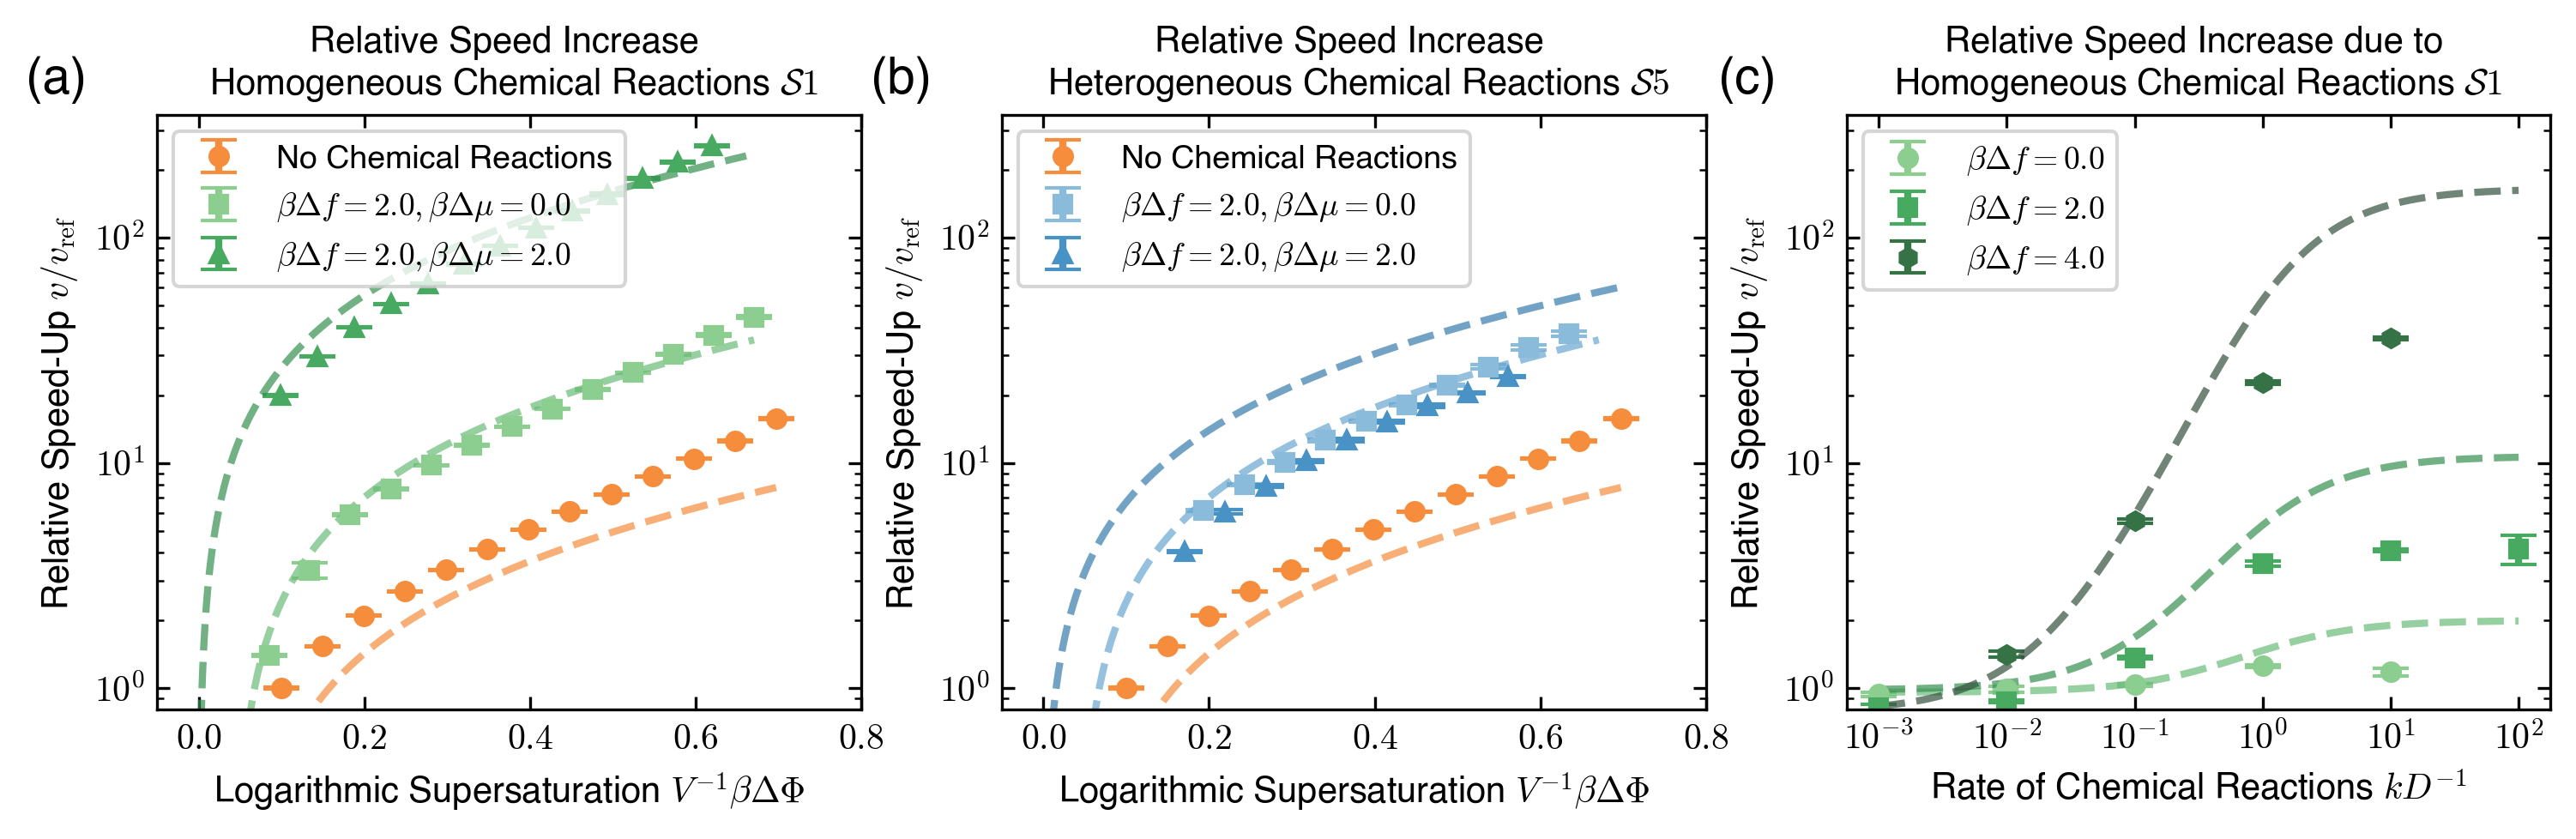

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
FS_LEGEND = 10

sites = 2 *80**2

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_BASELINE")
analysis = npa.DynamicalOrderDisorder("reference", base_path)
thermos = npa.Thermos(fres=-20.0, k=0)
no_chemical_reactions_numerical = analysis.get_data()
no_chemical_reactions_numerical["dphi"] = npa.calculate_dphi(no_chemical_reactions_numerical["mu"], thermos)
no_chemical_reactions_numerical = no_chemical_reactions_numerical.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
baseline_speed = no_chemical_reactions_numerical["growth_speed"].min()
no_chemical_reactions_numerical["growth_speed"] = no_chemical_reactions_numerical["growth_speed"] / baseline_speed
no_chemical_reactions_numerical["delta_growth_speed"] = no_chemical_reactions_numerical["delta_growth_speed"] / baseline_speed

axes[0].errorbar(no_chemical_reactions_numerical["dphi"], no_chemical_reactions_numerical["growth_speed"],yerr=no_chemical_reactions_numerical['delta_growth_speed'], lw=0, label='No Chemical Reactions', color=ORANGE,
                 ms=5, marker='o', capsize=5, elinewidth=2)

axes[1].errorbar(no_chemical_reactions_numerical["dphi"], no_chemical_reactions_numerical["growth_speed"],yerr=no_chemical_reactions_numerical['delta_growth_speed'], lw=0, label='No Chemical Reactions', color=ORANGE,
                 ms=5, marker='o', capsize=5, elinewidth=2)


############### LEFT PLOT ###############
# for S1: greens

colors = sns.color_palette(palette='Greens_d')

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D0_K1")
analysis = npa.DynamicalOrderDisorder("f2d0s1", base_path)
thermos = npa.Thermos(fres=2.0, k=1.0)
f2d0s1 = analysis.get_data()
f2d0s1["dphi"] = npa.calculate_dphi(f2d0s1["mu"], thermos)
f2d0s1 = f2d0s1.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
f2d0s1["growth_speed"] = f2d0s1["growth_speed"] / baseline_speed
f2d0s1["delta_growth_speed"] = f2d0s1["delta_growth_speed"] / baseline_speed

axes[0].errorbar(f2d0s1["dphi"], f2d0s1["growth_speed"],yerr=f2d0s1['delta_growth_speed'], lw=0, label=r'$\beta \Delta f = 2.0, \beta \Delta \mu = 0.0$', color=colors[0],
                 ms=5, marker='s', capsize=5, elinewidth=2)

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D2_K1")
analysis = npa.DynamicalOrderDisorder("f2d2s1", base_path)
thermos = npa.Thermos(fres=2.0, k=1.0, dmu=2.0, method='HOMO')
f2d2s1 = analysis.get_data()
f2d2s1["dphi"] = npa.calculate_dphi(f2d2s1["mu"], thermos)
f2d2s1 = f2d2s1.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
f2d2s1["growth_speed"] = f2d2s1["growth_speed"] / baseline_speed
f2d2s1["delta_growth_speed"] = f2d2s1["delta_growth_speed"] / baseline_speed

axes[0].errorbar(f2d2s1["dphi"], f2d2s1["growth_speed"],yerr=f2d2s1['delta_growth_speed'], lw=0, color=colors[2],
                 ms=5, marker='^', capsize=5, elinewidth=2, label=r"$\beta \Delta f = 2.0, \beta \Delta \mu = 2.0$")



axes[0].set_title('Relative Speed Increase \n Homogeneous Chemical Reactions' + r" $\mathcal{S}1$", fontsize=FS_LEGEND)


no_chemical_reactions_flex = pd.read_csv(
    "/Volumes/2025/2026/comparing_speeds/no_chemical_reactions_flex.csv"
)


axes[0].plot(
    no_chemical_reactions_flex["dphi"],
    no_chemical_reactions_flex["v_eff"] / baseline_speed,
    lw=2,
    color=ORANGE,
    alpha=0.7,
    ls="dashed",
)

axes[1].plot(
    no_chemical_reactions_flex["dphi"],
    no_chemical_reactions_flex["v_eff"] / baseline_speed,
    lw=2,
    color=ORANGE,
    alpha=0.7,
    ls="dashed",
)

no_chemical_reactions_flex = pd.read_csv(
    "/Volumes/2025/2026/comparing_speeds/df2_flex.csv"
)

axes[0].plot(
    no_chemical_reactions_flex["dphi"],
    no_chemical_reactions_flex["v_eff"] / baseline_speed,
    lw=2,
    color=colors[1],
    alpha=0.7,
    ls="dashed",
)



no_chemical_reactions_flex = pd.read_csv(
    "/Volumes/2025/2026/comparing_speeds/df2_dmu2_flex.csv"
)

axes[0].plot(
    no_chemical_reactions_flex["dphi"],
    no_chemical_reactions_flex["v_eff"] / baseline_speed,
    lw=2,
    color=colors[3],
    alpha=0.7,
    ls="dashed",
)


############### MIDDLE PLOT ###############
# for S6: blues

colors = sns.color_palette(palette='Blues_d')

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D0_K1_SCHEME6")
analysis = npa.DynamicalOrderDisorder("f2d0s6", base_path)
thermos = npa.Thermos(fres=2.0, k=1.0, method='SCHEME6', dmu=0.0)
f2d0s6 = analysis.get_data()
f2d0s6["dphi"] = npa.calculate_dphi(f2d0s6["mu"], thermos)
f2d0s6 = f2d0s6.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
f2d0s6["growth_speed"] = f2d0s6["growth_speed"] / baseline_speed
f2d0s6["delta_growth_speed"] = f2d0s6["delta_growth_speed"] / baseline_speed

axes[1].errorbar(f2d0s6["dphi"], f2d0s6["growth_speed"],yerr=f2d0s6['delta_growth_speed'], lw=0, label=r'$\beta \Delta f = 2.0, \beta \Delta \mu = 0.0$', color=colors[0],
                 ms=5, marker='s', capsize=5, elinewidth=2)

base_path = Path("/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D2_K1_SCHEME6")
analysis = npa.DynamicalOrderDisorder("f2d2s6", base_path)
thermos = npa.Thermos(fres=2.0, k=1.0, dmu=2.0, method='SCHEME6')
f2d2s6 = analysis.get_data()
f2d2s6["dphi"] = npa.calculate_dphi(f2d2s6["mu"], thermos)
f2d2s6 = f2d2s6.sort_values(
    by="dphi", ascending=True
).reset_index(drop=True)
f2d2s6["growth_speed"] = f2d2s6["growth_speed"] / baseline_speed
f2d2s6["delta_growth_speed"] = f2d2s6["delta_growth_speed"] / baseline_speed

axes[1].errorbar(f2d2s6["dphi"], f2d2s6["growth_speed"],yerr=f2d2s6['delta_growth_speed'], lw=0, color=colors[2],
                 ms=5, marker='^', capsize=5, elinewidth=2, label=r"$\beta \Delta f = 2.0, \beta \Delta \mu = 2.0$")








axes[1].set_title('Relative Speed Increase \n Heterogeneous Chemical Reactions' + r" $\mathcal{S}5$", fontsize=FS_LEGEND)


no_chemical_reactions_flex = pd.read_csv(
    "/Volumes/2025/2026/comparing_speeds/df2_flex.csv"
)

axes[1].plot(
    no_chemical_reactions_flex["dphi"],
    no_chemical_reactions_flex["v_eff"] / baseline_speed,
    lw=2,
    color=colors[1],
    alpha=0.7,
    ls="dashed",
)


no_chemical_reactions_flex = pd.read_csv(
    "/Volumes/2025/2026/comparing_speeds/df2_dmu2_flex.csv"
)

axes[1].plot(mu_space_df2_dmu_2_s6[mu_space_df2_dmu_2_s6 < 0.7], vs_df2_dmu_2_s6[mu_space_df2_dmu_2_s6 < 0.7] / baseline_speed, lw=2, color=colors[3], alpha=0.7, ls="dashed")
# axes[1].plot(mu_space_df2_dmu_2_s6, vs_df2_dmu_2_s6 / baseline_speed, lw=2, color=colors[3], alpha=0.7, ls="dashed")



for i in [0,1]:

    axes[i].set_yscale("log")
    axes[i].set_yticks(
        [1, 10, 100], [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$"], fontsize=FS_LEGEND
    )
    axes[i].set_ylim(0.8, 350)
    axes[i].set_ylabel(r"Relative Speed-Up $v / v_\mathrm{ref}$", fontsize=FS_LEGEND)

    axes[i].legend(fontsize=FS_LEGEND - 5)

    axes[i].set_xticks(
        [0.0, 0.2, 0.4, 0.6, 0.8],
        [r"$0.0$", "$0.2$", "$0.4$", "$0.6$", "$0.8$"],
        fontsize=FS_LEGEND,
    )
    axes[i].set_xlim(-0.05, 0.8)
    axes[i].set_xlabel(r"Logarithmic Supersaturation $V^{-1}\beta \Delta \Phi$", fontsize=FS_LEGEND)
    axes[i].legend(fontsize=FS_LEGEND - 1, loc='upper left')



# The right plot



colors = sns.color_palette(palette='Greens_d')


sites = 2 * 40**2

# df = 0.0

# k = np.array([0.001, 0.01, 0.1, 1.0, 10.0, 100.0])
# axes[2].errorbar(
#     k,
#     np.ones_like(k),
#     label=r"No Inactive States",
#     color=ORANGE,
#     ms=8,
#     marker="o",
#     ls="none",
#     capsize=8,
#     alpha=0.7,
#     zorder=0,
# )


rates = [0.001, 0.01, 0.1, 1.0, 10.0]
files = [
    Path("/Volumes/2025/2026/40_160_DFS/F0_K0001"),
    Path("/Volumes/2025/2026/40_160_DFS/F0_K001"),
    Path("/Volumes/2025/2026/40_160_DFS/F0_K01"),
    Path("/Volumes/2025/2026/40_160_DFS/F0_K1"),
    Path("/Volumes/2025/2026/40_160_DFS/F0_K10"),
]

dic = {"k": [], "speed": [], "yerr": []}
for k, f in zip(rates, files):
    analysis = npa.DynamicalOrderDisorder(f"f0_{k}", f)
    thermos = npa.Thermos(fres=0.0, k=k)
    data_k = analysis.get_data()
    data_k["dphi"] = npa.calculate_dphi(data_k["mu"], thermos)
    # print(data_k["dphi"].min())
    time = data_k["t"][data_k["dphi"] == data_k["dphi"].min()]
    # speed = float(1./time)
    # yerr = float(1./(data_k["dt"][data_k["dphi"] == data_k["dphi"].min()])/time**2)

    # speed /= ref_time
    # speed *= sites
    # yerr /= ref_time

    speed = (
        float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
    )
    yerr = (
        float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
        / ref_time
    )

    print(" df = 0.0")
    print(data_k["dphi"].min())

    dic["k"].append(k)
    dic["speed"].append(speed)
    dic["yerr"].append(yerr)

axes[2].errorbar(
    dic["k"],
    dic["speed"],
    yerr=dic["yerr"],
    label=r"$\beta \Delta f = 0.0$",
    color=colors[0],
    ms=5, marker='o', capsize=5, elinewidth=2,
    lw=0
)
# axes[2].errorbar(dic['k'], dic['speed'], yerr=dic['yerr'], fmt='o', color=blues[0], label="df0")


# df = 2.0

rates = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
files = [
    Path("/Volumes/2025/2026/40_160_DFS/F2_K0001"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K001"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K01"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K1"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K10"),
    Path("/Volumes/2025/2026/40_160_DFS/F2_K100"),
]

dic = {"k": [], "speed": [], "yerr": []}
for k, f in zip(rates, files):
    analysis = npa.DynamicalOrderDisorder(f"f2_{k}", f)
    thermos = npa.Thermos(fres=2.0, k=k)
    data_k = analysis.get_data()
    data_k["dphi"] = npa.calculate_dphi(data_k["mu"], thermos)
    time = data_k["t"][data_k["dphi"] == data_k["dphi"].min()]
    # speed = float(1./time)
    # yerr = float(1./(data_k["dt"][data_k["dphi"] == data_k["dphi"].min()])/(time**2))
    # speed /= ref_time
    # speed *= sites
    # yerr /= ref_time
    # print(speed)

    print(" df = 2.0")
    print(data_k["dphi"].min())

    speed = (
        float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
    )
    yerr = (
        float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
        / ref_time
    )

    dic["k"].append(k)
    dic["speed"].append(speed)
    dic["yerr"].append(yerr)

axes[2].errorbar(
    dic["k"],
    dic["speed"],
    yerr=dic["yerr"],
    label=r"$\beta \Delta f = 2.0$",
    color=colors[2],
    ms=5, marker='s', capsize=5, elinewidth=2,
    lw=0
)

# axes[2].errorbar(dic['k'], dic['speed'], yerr=dic['yerr'], fmt='s', color=blues[2], label="df2")


# df = 4.0

rates = [0.01, 0.1, 1.0, 10.0]
files = [
    Path("/Volumes/2025/2026/40_160_DFS/F4_K001"),
    Path("/Volumes/2025/2026/40_160_DFS/F4_K01"),
    Path("/Volumes/2025/2026/40_160_DFS/F4_K1"),
    Path("/Volumes/2025/2026/40_160_DFS/F4_K10"),
]
dic = {"k": [], "speed": [], "yerr": []}
for k, f in zip(rates, files):
    analysis = npa.DynamicalOrderDisorder(f"f4_{k}", f)
    thermos = npa.Thermos(fres=4.0, k=k)
    data_k = analysis.get_data()
    data_k["dphi"] = npa.calculate_dphi(data_k["mu"], thermos)
    # time = data_k["t"][data_k["dphi"] == data_k["dphi"].min()]
    # speed = float(1./time)
    # yerr = float(1./(data_k["dt"][data_k["dphi"] == data_k["dphi"].min()])/time**2)
    # speed /= ref_time
    # speed *= sites
    # yerr /= ref_time
    speed = (
        float(data_k["growth_speed"][data_k["dphi"] == data_k["dphi"].min()]) / ref_time
    )

    yerr = (
        float(data_k["delta_growth_speed"][data_k["dphi"] == data_k["dphi"].min()])
        / ref_time
    )
    # print('yerr:', yerr)

    print(" df = 4.0")
    print(data_k["dphi"].min())

    dic["k"].append(k)
    dic["speed"].append(speed)
    dic["yerr"].append(yerr)

axes[2].errorbar(
    dic["k"],
    dic["speed"],
    yerr=dic["yerr"],
    label=r"$\beta \Delta f = 4.0$",
    color=colors[4],
    ms=5, marker='h', capsize=5, elinewidth=2,
    lw=0
)

# axes[2].errorbar(dic['k'], dic['speed'], yerr=dic['yerr'], fmt='h', color=blues[4], label="df4")


axes[2].plot(
    k_range, np.array(v_effs_f0), lw=2, color=colors[1], alpha=0.7, ls="dashed"
)
axes[2].plot(
    k_range, np.array(v_effs_f2), lw=2, color=colors[3], alpha=0.7, ls="dashed"
)
axes[2].plot(
    k_range, np.array(v_effs_f4), lw=2, color=colors[5], alpha=0.7, ls="dashed"
)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel(r"Rate of Chemical Reactions $kD^{-1}$", fontsize=FS_LEGEND)
axes[2].set_ylabel(r"Relative Speed-Up $v / v_\mathrm{ref}$", fontsize=FS_LEGEND)

axes[2].set_yticks(
    [1, 10, 100], [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$"], fontsize=FS_LEGEND
)
axes[2].set_ylim(0.8, 350)
axes[2].set_xticks(
    [0.001, 0.01, 0.1, 1, 10, 100], [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$"], fontsize=FS_LEGEND
)

axes[2].legend(fontsize=FS_LEGEND - 1, loc='upper left')


axes[2].set_title('Relative Speed Increase due to \nHomogeneous Chemical Reactions' + r" $\mathcal{S}1$", fontsize=FS_LEGEND)

axes[0].text(
    -0.1,
    1.1,
    "(a)",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
)

axes[1].text(
    -0.1,
    1.1,
    "(b)",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
)

axes[2].text(
    -0.1,
    1.1,
    "(c)",
    transform=axes[2].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="right",
)

plt.savefig("speeds.pdf", dpi=300, bbox_inches="tight")

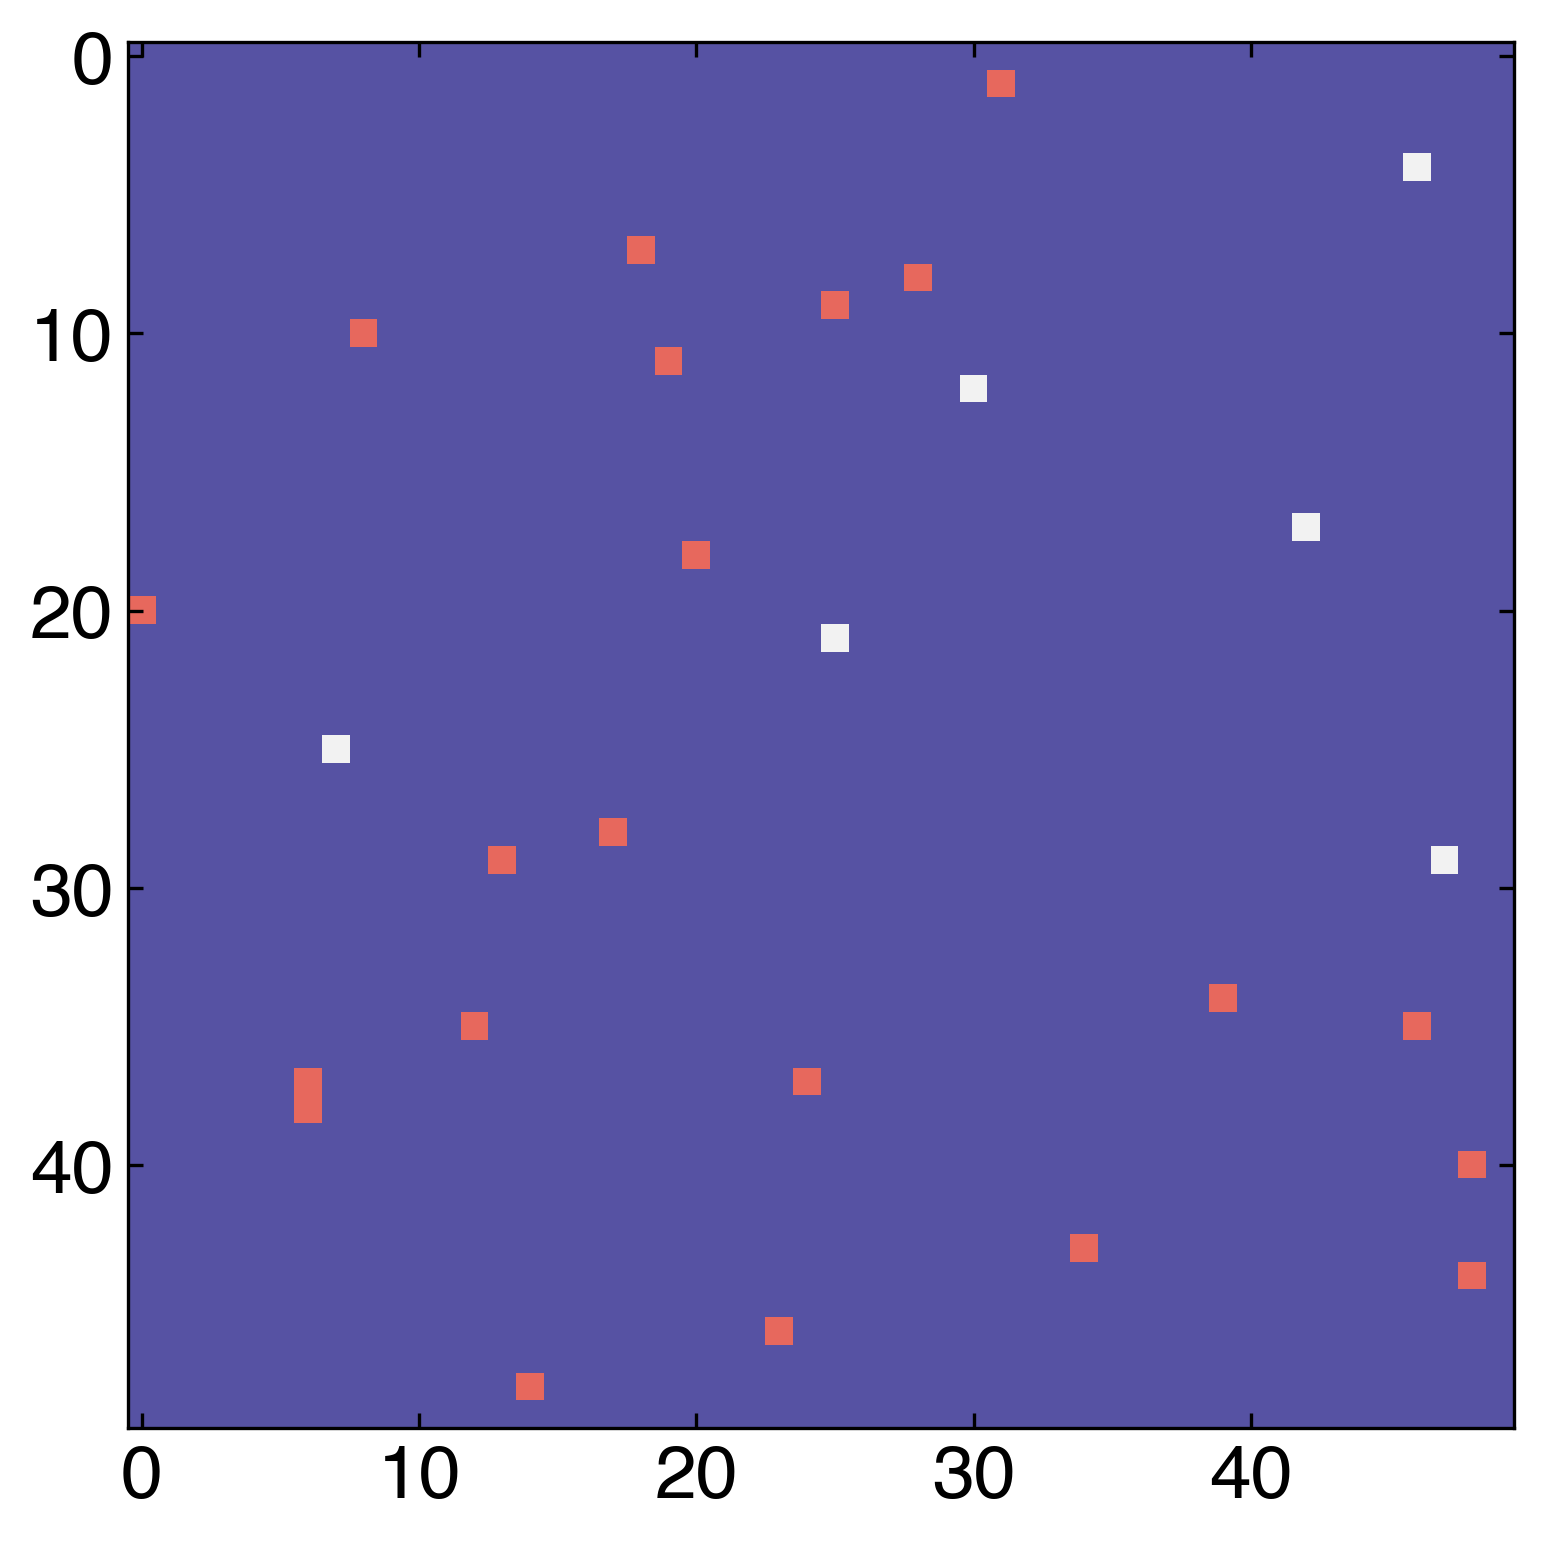

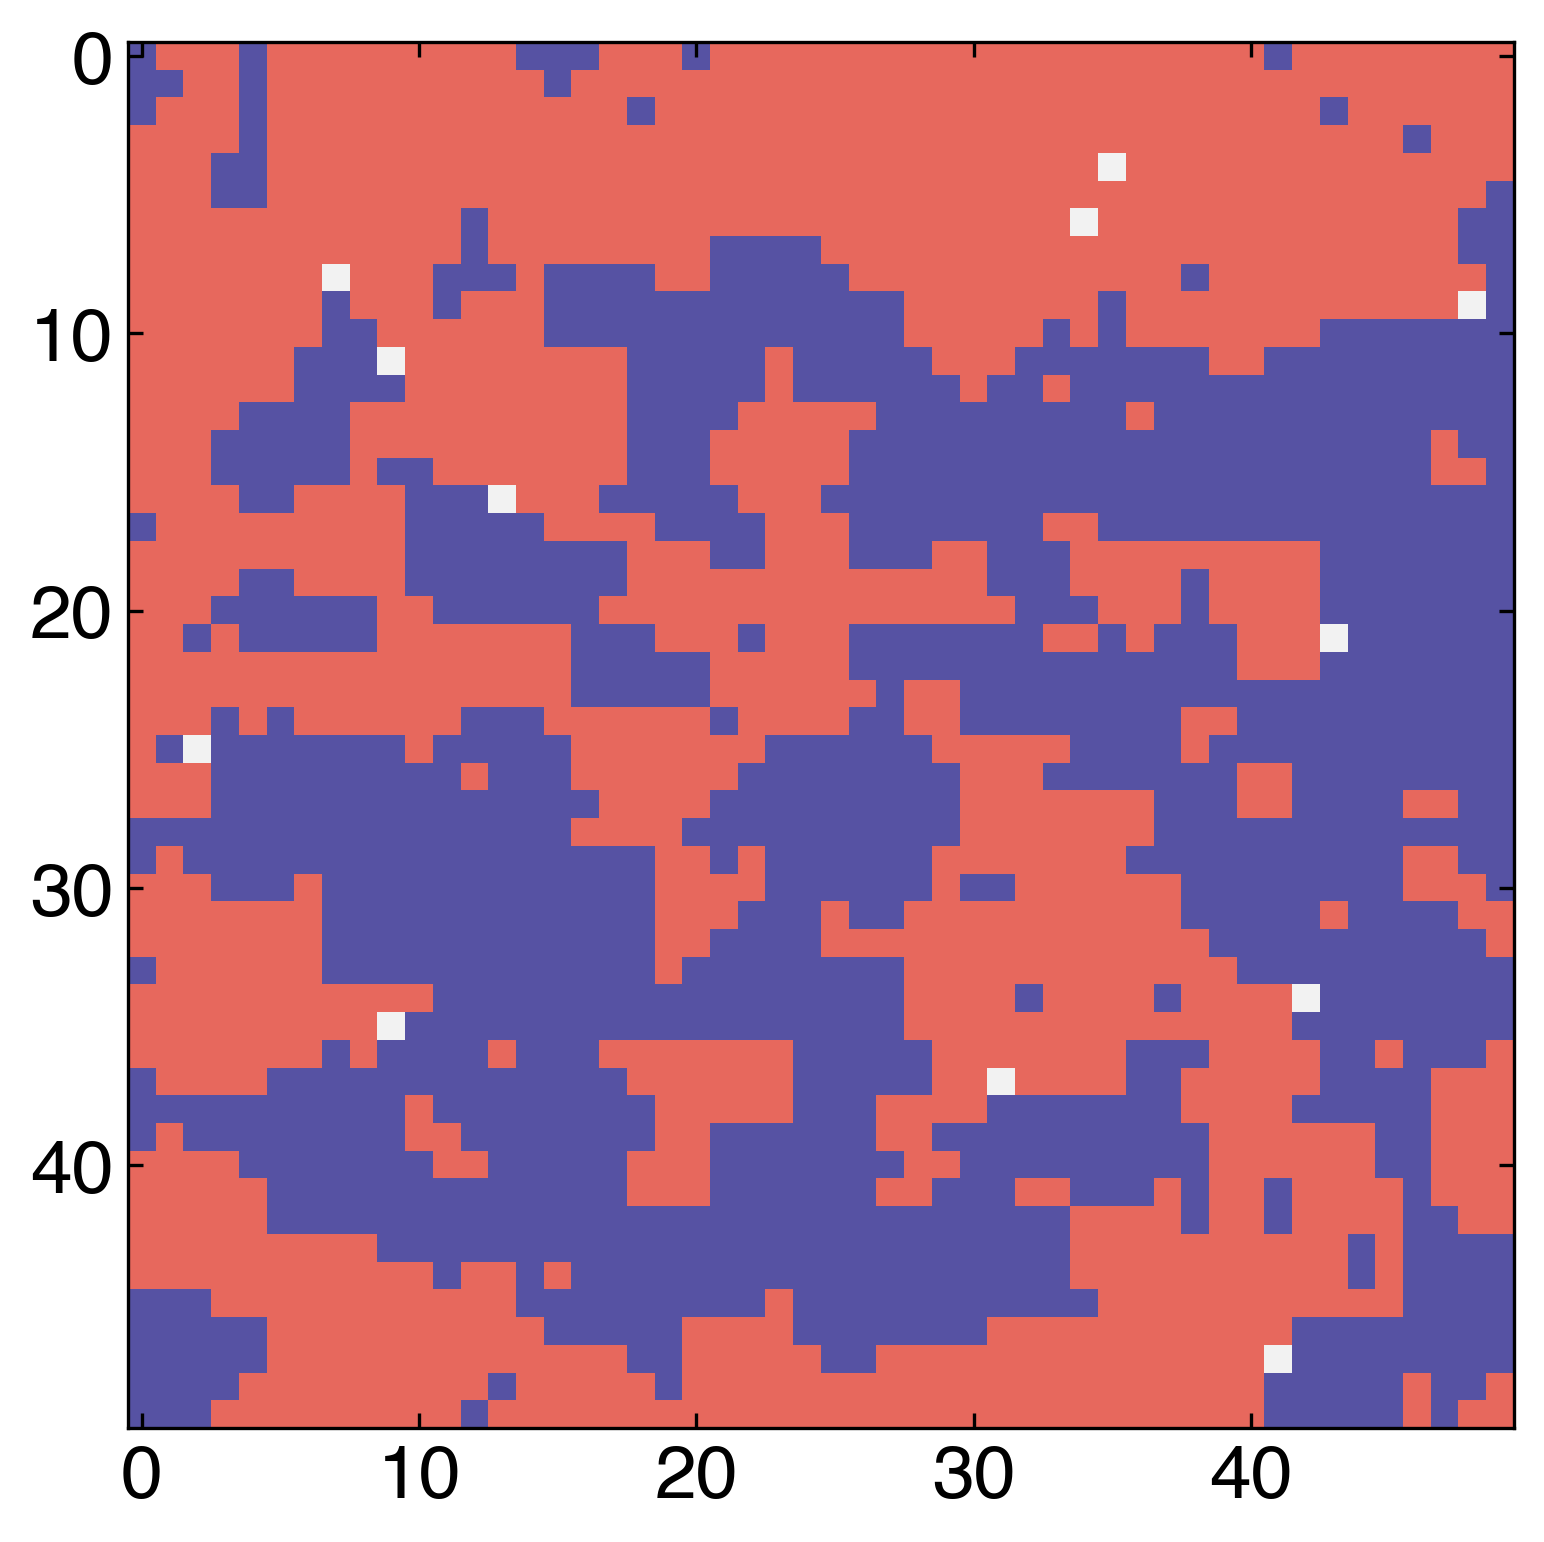

In [12]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#f2f2f2", "#f2f2f2", "#f2f2f2", "#e7685d", "#5652a3"])
norm = plt.Normalize(vmin=-2, vmax=2)
lattice = np.load('/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D2_K1_SCHEME6/-6.19/2026-03-24-13:43_2/lattice_final.npy')
plt.imshow(lattice[0:50, 150:200], cmap=cmap, norm=norm, interpolation="none")
plt.show()

lattice = np.load('/Volumes/2025/2026_paper/SPEEDS/80x320_F2_D0_K1_SCHEME6/-6.34/2026-03-24-13:43_2/lattice_final.npy')
plt.imshow(lattice[0:50, 150:200], cmap=cmap, norm=norm, interpolation="none")